# CRS Screen for Discretionary Trading

## Top & Bottom Decile Watchlists — S&P 500 and Russell 1000

**Purpose.** This notebook produces two live watchlists — one for S&P 500 constituents, one for Russell 1000 — refreshed on a 5-trading-day cadence. For each universe, it identifies:

- **D1 (top decile)** — candidates for long consideration
- **D10 (bottom decile)** — candidates for short consideration (or avoidance)

The lists are intended as a starting point for discretionary trade selection, not a mechanical signal. The final decision about which names to trade rests with the trader.

## Methodology

### CRS formula

Identical to `CRS_v6_2_CrisisAlpha`:

$$\text{CRS}_t = P_t \cdot \left(\frac{2}{P_{t-21}} + \frac{1}{P_{t-63}} + \frac{1}{P_{t-126}}\right)$$

Higher CRS values indicate stronger relative strength (positive momentum across the 21/63/126-day lookbacks, with the 21-day component weighted 2×). The formula is the TC2000 Comparative Relative Strength formulation.

### Refresh cadence

Every 5 trading days (weekly). The last refresh date in the data drives the most recent watchlist snapshot.

### Decile construction

At each rebalance date, the universe is ranked by CRS and split into 10 equal buckets. D1 is the top 10% (~50 names for S&P 500, ~100 for Russell 1000). D10 is the bottom 10%.

### Equity curve construction

For each rebalance date, D1 (long) and D10 (short) baskets are formed equal-weight. Positions are held until the next rebalance. No stops, no transaction costs — this is a reference curve for screen quality, not a trading strategy.

- **D1 long equity curve:** cumulative equal-weight return of D1 names held period-to-period
- **D10 short equity curve:** cumulative equal-weight return of a short position in D10 names (i.e., the inverse of D10's long return compounded)
- **EW benchmark:** equal-weight return of the full universe, rebalanced on the same schedule
- **Relative performance:** D1_long / EW_benchmark and D10_short / EW_benchmark — values above 1.0 indicate outperformance

---
## 1. Environment & Configuration

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import urllib.request
from io import StringIO
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ------------------ CRS SCREEN CONFIGURATION ------------------

# Refresh cadence: every 5 trading days
REBAL_PERIOD = 5

# Decile construction
N_DECILES = 10

# CRS lookbacks (identical to CRS_v6_2_CrisisAlpha)
LOOKBACKS = (21, 63, 126)        # days
WEIGHTS   = (2.0, 1.0, 1.0)      # TC2000 weighting

# Data window
END_DATE   = datetime.today().strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=365 * 4)).strftime('%Y-%m-%d')
# ~4 years of data gives ~3 years of equity curve after the 126-day CRS warmup

print("CRS Discretionary Screen — Configuration")
print("=" * 60)
print(f"  Rebalance cadence:  every {REBAL_PERIOD} trading days")
print(f"  CRS lookbacks:      {LOOKBACKS} (weights: {WEIGHTS})")
print(f"  Deciles:            {N_DECILES}")
print(f"  Data window:        {START_DATE} → {END_DATE}")

CRS Discretionary Screen — Configuration
  Rebalance cadence:  every 5 trading days
  CRS lookbacks:      (21, 63, 126) (weights: (2.0, 1.0, 1.0))
  Deciles:            10
  Data window:        2022-04-17 → 2026-04-16


---
## 2. Universe Construction

Both universes are fetched live:

- **S&P 500**: `datasets/s-and-p-500-companies` GitHub mirror (Wikipedia-sourced, updated daily)
- **Russell 1000**: iShares IWB ETF holdings CSV (the canonical live source for Russell 1000 constituents; provided by BlackRock and updated daily)

Tickers are normalized to yfinance's dash-separator format for dual-class shares (e.g., `BRK.B` → `BRK-B`, `BRKB` → `BRK-B`).

In [2]:
import time
import logging
import contextlib
import io

# Suppress yfinance's verbose logging for failed-ticker warnings.
# iShares IWB includes a handful of tickers that don't resolve on yfinance
# (structural quirks in BlackRock's holdings file). They're silently dropped
# by the min_days filter in download_prices() — no logic impact, just cosmetic.
logging.getLogger('yfinance').setLevel(logging.CRITICAL)


# ---------------------------------------------------------------------
# Canonical dual-class ticker mapping: iShares form → yfinance form
# ---------------------------------------------------------------------
# Empirically determined: of 24 iShares Russell 1000 tickers ending in A/B/C/D
# with "CLASS" in their name, only these 5 require dash-insertion to resolve
# on yfinance. The other 19 (META, CMCSA, CRWD, FOXA, OKTA, GTLB, UWMC,
# FWONA, LBTYA, LLYVA, LBRDA, GLIBA, etc.) are plain yfinance tickers and
# should be left alone.
#
# Re-verify this list whenever iShares adds new dual-class constituents.
IWB_DUAL_CLASS_MAP = {
    'BRKB':  'BRK-B',    # Berkshire Hathaway Class B
    'BFB':   'BF-B',     # Brown-Forman Class B
    'BFA':   'BF-A',     # Brown-Forman Class A
    'HEIA':  'HEI-A',    # HEICO Class A
    'UHALB': 'UHAL-B',   # U-Haul Holdings Class B
    'CWENA': 'CWEN-A',   # Clearway Energy Class A
    'LENB':  'LEN-B',    # Lennar Class B
}


def get_sp500_tickers():
    """Fetch current S&P 500 constituents from the datasets/s-and-p-500-companies mirror.
    Source uses dots for dual-class (BRK.B) which we normalize to yfinance dash format."""
    urls = [
        'https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv',
        'https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv',
    ]
    for url in urls:
        try:
            df = pd.read_csv(url)
            tickers = sorted(df['Symbol'].str.replace('.', '-', regex=False).tolist())
            return tickers
        except Exception:
            continue
    raise RuntimeError("Failed to fetch S&P 500 tickers from all sources")


def _normalize_iwb_ticker(ticker):
    """
    Normalize an iShares IWB ticker to yfinance format.
    Only applies the explicit dual-class mapping — never modifies other tickers.
    """
    return IWB_DUAL_CLASS_MAP.get(ticker, ticker)


def get_russell1000_tickers(max_retries=5, backoff_base=3):
    """
    Fetch current Russell 1000 constituents from iShares IWB ETF holdings.
    Retries on 5xx errors, then applies the canonical dual-class normalization.
    """
    iwb_url = ("https://www.ishares.com/us/products/239707/ishares-russell-1000-etf/"
               "1467271812596.ajax?fileType=csv&fileName=IWB_holdings&dataType=fund")

    raw = None
    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            req = urllib.request.Request(iwb_url, headers={
                'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
                              'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36',
                'Accept': 'text/csv,application/json,*/*',
                'Accept-Language': 'en-US,en;q=0.9',
            })
            with urllib.request.urlopen(req, timeout=30) as resp:
                raw = resp.read().decode('utf-8', errors='ignore')
            break
        except Exception as e:
            last_err = e
            if attempt < max_retries:
                sleep_s = backoff_base * attempt
                print(f"    iShares IWB fetch attempt {attempt}/{max_retries} failed "
                      f"({e}). Retrying in {sleep_s}s…")
                time.sleep(sleep_s)
    if raw is None:
        raise RuntimeError(
            f"Failed to fetch iShares IWB holdings after {max_retries} attempts. "
            f"Last error: {last_err}."
        )

    # iShares CSV has metadata rows before the actual data. Find the "Ticker" header.
    lines = raw.split('\n')
    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith('Ticker'):
            header_idx = i
            break
    if header_idx is None:
        raise RuntimeError("Could not parse iShares IWB CSV — no Ticker header row")

    df = pd.read_csv(StringIO('\n'.join(lines[header_idx:])))
    df = df[df['Asset Class'] == 'Equity']
    raw_tickers = [t for t in df['Ticker'].tolist()
                   if isinstance(t, str) and t not in ('-', '')]

    # Apply canonical dual-class mapping. No heuristic dash-insertion — anything
    # not in the explicit mapping is left alone.
    normalized = sorted(set(_normalize_iwb_ticker(t) for t in raw_tickers))
    return normalized


def download_prices(tickers, start, end, min_days=126):
    """Download adjusted close prices. Silently drops tickers with insufficient data.
    
    yfinance warnings about delisted tickers are suppressed — iShares includes a small
    number of instruments (typically 3-8) that don't resolve on Yahoo Finance. These
    are filtered out by the min_days threshold below.
    """
    print(f"  Downloading {len(tickers)} tickers from {start} → {end}…")
    
    # Suppress yfinance's per-ticker failure spam by redirecting stderr during the call
    stderr_buffer = io.StringIO()
    with contextlib.redirect_stderr(stderr_buffer):
        data = yf.download(tickers, start=start, end=end, auto_adjust=True,
                           threads=True, progress=False)
    
    close = data['Close'] if isinstance(data.columns, pd.MultiIndex) else data
    close = close.ffill(limit=3)
    keep = close.columns[close.notna().sum() >= min_days]
    dropped = len(close.columns) - len(keep)
    close = close[keep]
    
    # Report dropped tickers concisely — no stack traces or per-ticker lines
    print(f"    Retrieved {len(close.columns)} usable tickers "
          f"(dropped {dropped} with < {min_days} days of data), "
          f"{len(close)} trading days")
    if dropped > 0 and dropped <= 20:
        # Show which tickers were dropped when it's a manageable number
        dropped_list = sorted(set(close.columns.tolist()) ^ set(tickers) |
                              (set(tickers) - set(close.columns.tolist())))
        # Simpler: tickers we asked for but aren't in keep
        not_kept = sorted(set(tickers) - set(keep.tolist()))
        if not_kept:
            print(f"    Dropped: {', '.join(not_kept[:20])}"
                  + (f" (+{len(not_kept)-20} more)" if len(not_kept) > 20 else ""))
    return close


# -----------------------------------------------------------------
# Fetch both universes
# -----------------------------------------------------------------
print("[1/2] Fetching S&P 500 constituents…")
spx_tickers = get_sp500_tickers()
print(f"      Got {len(spx_tickers)} S&P 500 tickers")

print("[2/2] Fetching Russell 1000 constituents…")
r1k_tickers = get_russell1000_tickers()
print(f"      Got {len(r1k_tickers)} Russell 1000 tickers (before yfinance validation)")

[1/2] Fetching S&P 500 constituents…
      Got 503 S&P 500 tickers
[2/2] Fetching Russell 1000 constituents…
      Got 1003 Russell 1000 tickers (before yfinance validation)


      Got 1003 Russell 1000 tickers (before yfinance validation)


---
## 3. CRS Signal & Decile Assignment

At each of the latest `REBAL_PERIOD`-day rebalance dates, we rank the universe by CRS
and split into `N_DECILES` equal buckets. D1 is the top decile (strongest relative
strength), D10 is the bottom decile (weakest).

In [3]:
def compute_crs_matrix(close_prices, lookbacks=(21, 63, 126), weights=(2.0, 1.0, 1.0)):
    """
    Compute Comparative Relative Strength (TC2000 formulation).
    
    CRS[t] = P[t] * sum_i weights[i] / P[t - lookbacks[i]]
    
    No look-ahead: all shifts are strictly positive, so CRS at time t uses
    only data from dates <= t.
    """
    c = close_prices
    components = []
    for lb, w in zip(lookbacks, weights):
        components.append(w / c.shift(lb))
    crs = c * sum(components)
    return crs.replace([np.inf, -np.inf], np.nan)


def assign_deciles(crs_row, n_deciles=10):
    """
    Rank the cross-section by CRS and assign decile labels 1-10.
    Decile 1 = highest CRS (strongest).
    Decile 10 = lowest CRS (weakest).
    Returns None if fewer than n_deciles*2 valid observations.
    """
    valid = crs_row.dropna()
    if len(valid) < n_deciles * 2:
        return None
    ranks = valid.rank(ascending=False, method='first')
    decile_size = len(valid) / n_deciles
    deciles = np.ceil(ranks / decile_size).astype(int).clip(1, n_deciles)
    return deciles


print("CRS & decile functions defined.")

CRS & decile functions defined.


---
## 4. Equity Curve Construction

For each universe, we walk through the history every `REBAL_PERIOD` trading days:

1. Rank names by CRS, assign deciles
2. Form equal-weight D1 and D10 baskets
3. Hold until the next rebalance date; compute daily returns for each basket
4. Also compute the equal-weight benchmark (full universe, same rebalance schedule)

**D10 short curve.** For the bottom-decile curve, we treat each period's basket as
a short position. The basket's long return is $r_{long}$; the short return is
$r_{short} = -r_{long}$, compounded normally day-to-day:
$$V_{short}(t) = V_{short}(t-1) \cdot (1 + r_{short}(t))$$

This gives a curve that rises when weak names underperform and falls when they bounce —
the right visualization for a short-side watchlist.

**Relative performance.** Two ratio lines are plotted:
- `D1 / EW_benchmark` → values > 1 mean D1 outperforming the benchmark cumulatively
- `D10_short / EW_benchmark` → values > 1 mean a short in D10 outperforming being long the benchmark

In [4]:
def run_decile_screen(close_prices, rebal_period=5, n_deciles=10,
                      lookbacks=(21, 63, 126), weights=(2.0, 1.0, 1.0)):
    """
    Walk through history and compute D1 (top), D10 (bottom), and equal-weight
    benchmark daily returns with the specified rebalance cadence.
    
    Also returns a DataFrame of decile assignments at each rebalance date,
    which is used to extract the current watchlist.
    
    Returns
    -------
    dict with keys:
      'd1_returns'  : pd.Series of D1 (long) daily returns
      'd10_returns' : pd.Series of D10 (long) daily returns — NOT inverted
      'ew_returns'  : pd.Series of EW benchmark daily returns
      'd1_members'  : dict mapping rebal_date → list of D1 tickers
      'd10_members' : dict mapping rebal_date → list of D10 tickers
      'rebal_dates' : list of rebalance datetimes
    """
    crs = compute_crs_matrix(close_prices, lookbacks, weights)
    daily_rets = close_prices.pct_change()

    first_valid = crs.dropna(how='all').index[0]
    valid_dates = close_prices.index[close_prices.index >= first_valid]
    rebal_dates = valid_dates[::rebal_period]

    d1_out, d10_out, ew_out = {}, {}, {}
    d1_members, d10_members = {}, {}

    for i in range(len(rebal_dates)):
        reb = rebal_dates[i]
        nxt = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else valid_dates[-1]
        fwd_mask = (close_prices.index > reb) & (close_prices.index <= nxt)
        fwd_dates = close_prices.index[fwd_mask]
        if len(fwd_dates) == 0:
            continue

        # Decile assignment
        deciles = assign_deciles(crs.loc[reb], n_deciles)
        if deciles is None:
            continue
        d1_stocks = deciles[deciles == 1].index.tolist()
        d10_stocks = deciles[deciles == n_deciles].index.tolist()
        ew_stocks = deciles.index.tolist()

        d1_members[reb] = d1_stocks
        d10_members[reb] = d10_stocks

        # Forward returns: equal-weight average across the basket each day
        d1_cols = [c for c in d1_stocks if c in daily_rets.columns]
        d10_cols = [c for c in d10_stocks if c in daily_rets.columns]
        ew_cols = [c for c in ew_stocks if c in daily_rets.columns]

        d1_rets = daily_rets.loc[fwd_dates, d1_cols].mean(axis=1) if d1_cols else pd.Series(0.0, index=fwd_dates)
        d10_rets = daily_rets.loc[fwd_dates, d10_cols].mean(axis=1) if d10_cols else pd.Series(0.0, index=fwd_dates)
        ew_rets = daily_rets.loc[fwd_dates, ew_cols].mean(axis=1) if ew_cols else pd.Series(0.0, index=fwd_dates)

        for dt in fwd_dates:
            d1_out[dt] = d1_rets.loc[dt]
            d10_out[dt] = d10_rets.loc[dt]
            ew_out[dt] = ew_rets.loc[dt]

    return {
        'd1_returns':  pd.Series(d1_out).sort_index(),
        'd10_returns': pd.Series(d10_out).sort_index(),
        'ew_returns':  pd.Series(ew_out).sort_index(),
        'd1_members':  d1_members,
        'd10_members': d10_members,
        'rebal_dates': list(rebal_dates),
    }


def build_equity_curves(backtest_output):
    """
    Build equity curves for D1 long, D10 short, and EW benchmark.
    Also compute relative performance ratios.
    Each curve starts at 1.0 on the first trading day.
    """
    d1 = backtest_output['d1_returns']
    d10 = backtest_output['d10_returns']
    ew = backtest_output['ew_returns']

    d1_long_eq = (1 + d1).cumprod()
    d10_short_eq = (1 + (-d10)).cumprod()   # negate daily return then compound
    ew_eq = (1 + ew).cumprod()

    # Align indices to be safe
    df = pd.DataFrame({
        'D1_long':      d1_long_eq,
        'D10_short':    d10_short_eq,
        'EW_benchmark': ew_eq,
    }).dropna()

    # Relative performance: strategy curve / benchmark curve
    # Values > 1 mean cumulative outperformance vs the benchmark
    df['D1_vs_EW']       = df['D1_long']   / df['EW_benchmark']
    df['D10_short_vs_EW'] = df['D10_short'] / df['EW_benchmark']

    return df


print("Backtest engine defined.")

Backtest engine defined.


---
## 5. Run the Screen on Both Universes

Download price data for S&P 500 and Russell 1000, then run the decile screen on each.
The Russell 1000 download takes longer (~2× the ticker count).

In [5]:
# -------- S&P 500 --------
print("=" * 70)
print("  S&P 500 SCREEN")
print("=" * 70)
spx_prices = download_prices(spx_tickers, START_DATE, END_DATE, min_days=126)
spx_bt = run_decile_screen(spx_prices, REBAL_PERIOD, N_DECILES, LOOKBACKS, WEIGHTS)
spx_eq = build_equity_curves(spx_bt)
print(f"  Equity curves computed: {len(spx_eq)} trading days")
print(f"  Rebalances: {len(spx_bt['rebal_dates'])}")
print(f"  Most recent rebalance: {max(spx_bt['d1_members'].keys()).date()}")
print(f"  D1 size (most recent): {len(spx_bt['d1_members'][max(spx_bt['d1_members'].keys())])}")
print(f"  D10 size (most recent): {len(spx_bt['d10_members'][max(spx_bt['d10_members'].keys())])}")

# -------- Russell 1000 --------
print("\n" + "=" * 70)
print("  RUSSELL 1000 SCREEN")
print("=" * 70)
r1k_prices = download_prices(r1k_tickers, START_DATE, END_DATE, min_days=126)
r1k_bt = run_decile_screen(r1k_prices, REBAL_PERIOD, N_DECILES, LOOKBACKS, WEIGHTS)
r1k_eq = build_equity_curves(r1k_bt)
print(f"  Equity curves computed: {len(r1k_eq)} trading days")
print(f"  Rebalances: {len(r1k_bt['rebal_dates'])}")
print(f"  Most recent rebalance: {max(r1k_bt['d1_members'].keys()).date()}")
print(f"  D1 size (most recent): {len(r1k_bt['d1_members'][max(r1k_bt['d1_members'].keys())])}")
print(f"  D10 size (most recent): {len(r1k_bt['d10_members'][max(r1k_bt['d10_members'].keys())])}")

  S&P 500 SCREEN
    Retrieved 502 usable tickers (dropped 1 with < 126 days of data), 1002 trading days
    Dropped: Q
  Equity curves computed: 875 trading days
  Rebalances: 176
  Most recent rebalance: 2026-04-08
  D1 size (most recent): 50
  D10 size (most recent): 51

  RUSSELL 1000 SCREEN
    Retrieved 997 usable tickers (dropped 6 with < 126 days of data), 1002 trading days
    Dropped: CBC, MDLN, Q, SOLS, VGNT, VSNT
  Equity curves computed: 875 trading days
  Rebalances: 176
  Most recent rebalance: 2026-04-08
  D1 size (most recent): 99
  D10 size (most recent): 100


    Retrieved 502 usable tickers (dropped 1 with < 126 days of data), 1002 trading days
    Dropped: Q


  Equity curves computed: 875 trading days
  Rebalances: 176
  Most recent rebalance: 2026-04-08
  D1 size (most recent): 50
  D10 size (most recent): 51

  RUSSELL 1000 SCREEN


    Retrieved 997 usable tickers (dropped 6 with < 126 days of data), 1002 trading days
    Dropped: CBC, MDLN, Q, SOLS, VGNT, VSNT


  Equity curves computed: 875 trading days
  Rebalances: 176
  Most recent rebalance: 2026-04-08
  D1 size (most recent): 99
  D10 size (most recent): 100


---
## 6. Visualization — Equity Curves & Relative Performance

Two figures, one per universe. Each figure has two panels:

**Top panel (absolute equity curves)** — starts at $1, shows cumulative $-growth for:
- D1 long (top decile, bought equal-weight every 5 days)
- D10 short (bottom decile, shorted equal-weight every 5 days)
- EW benchmark (full universe, equal-weight, same rebalance schedule)

**Bottom panel (relative performance ratios)** — starts at 1.0, shows cumulative
outperformance vs the EW benchmark. Above 1.0 = outperforming the benchmark.

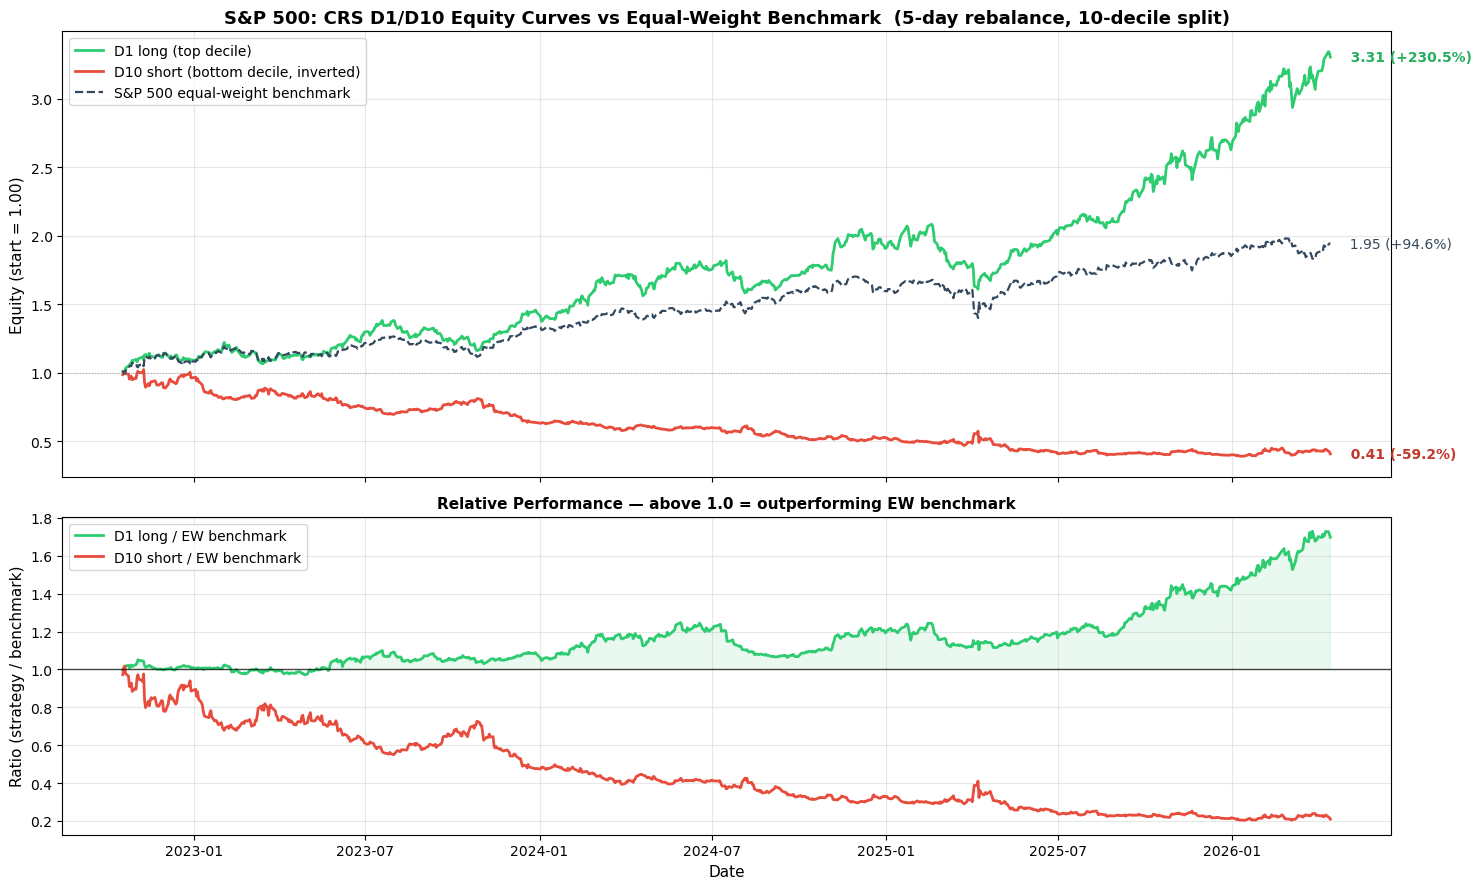

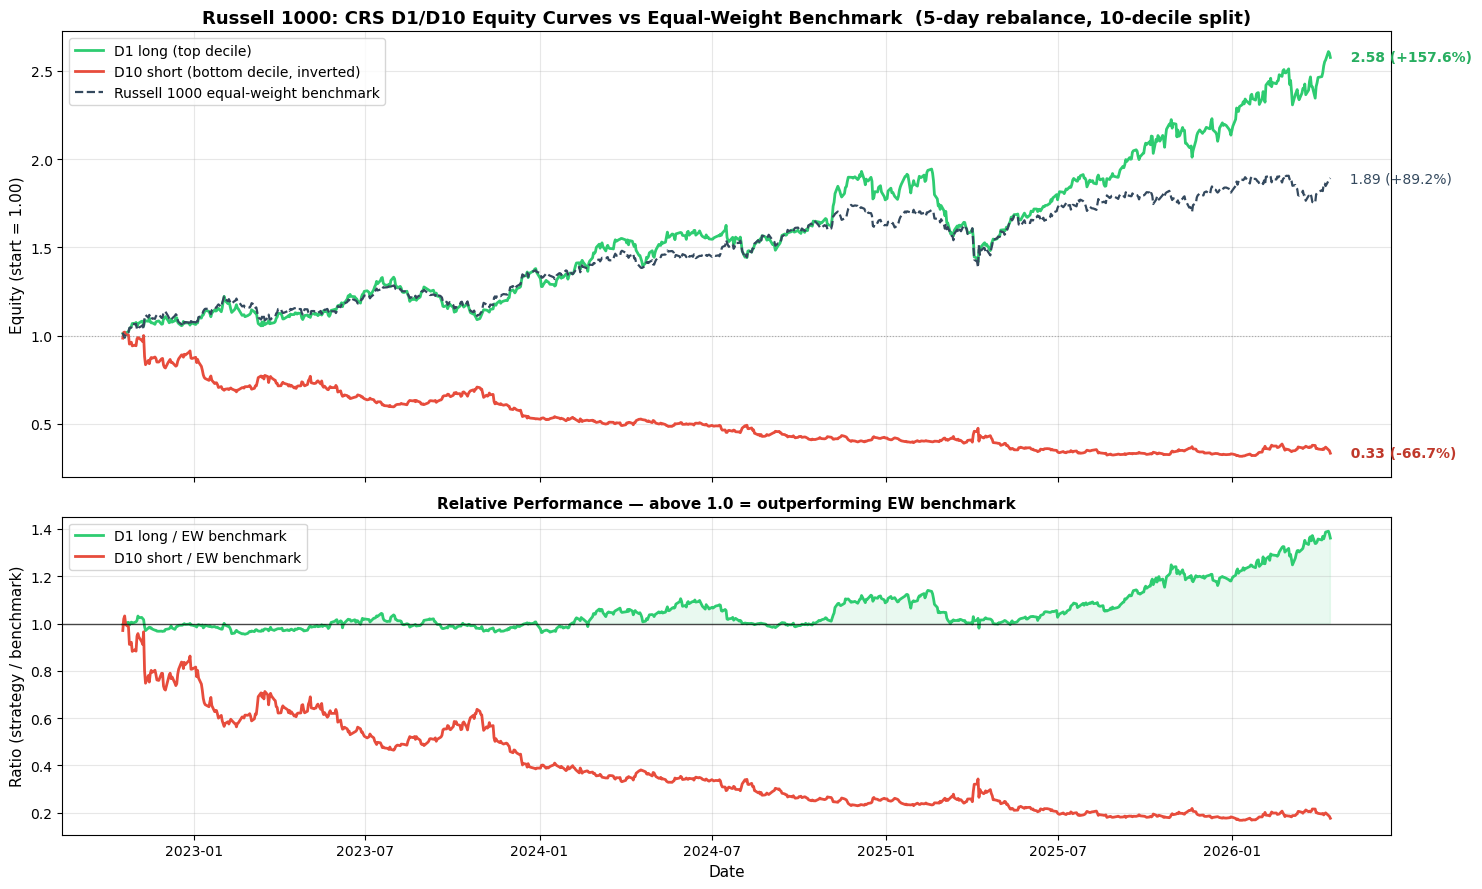

In [6]:
def plot_universe_curves(eq_df, universe_label):
    """Two-panel plot: absolute equity curves on top, relative performance on bottom."""
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                             gridspec_kw={'height_ratios': [1.4, 1]})

    # -------- Panel 1: Absolute equity curves --------
    ax = axes[0]
    ax.plot(eq_df.index, eq_df['D1_long'],
            label='D1 long (top decile)', color='#2ecc71', linewidth=2.0)
    ax.plot(eq_df.index, eq_df['D10_short'],
            label='D10 short (bottom decile, inverted)',
            color='#e74c3c', linewidth=2.0)
    ax.plot(eq_df.index, eq_df['EW_benchmark'],
            label=f'{universe_label} equal-weight benchmark',
            color='#34495e', linewidth=1.6, linestyle='--')

    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_ylabel('Equity (start = 1.00)', fontsize=11)
    ax.set_title(f'{universe_label}: CRS D1/D10 Equity Curves vs Equal-Weight Benchmark  '
                 f'(5-day rebalance, {N_DECILES}-decile split)',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    # Annotate final values
    final = eq_df.iloc[-1]
    ax.annotate(f"  {final['D1_long']:.2f} ({(final['D1_long']-1)*100:+.1f}%)",
                xy=(eq_df.index[-1], final['D1_long']),
                xytext=(8, 0), textcoords='offset points',
                color='#27ae60', fontsize=10, fontweight='bold', va='center')
    ax.annotate(f"  {final['D10_short']:.2f} ({(final['D10_short']-1)*100:+.1f}%)",
                xy=(eq_df.index[-1], final['D10_short']),
                xytext=(8, 0), textcoords='offset points',
                color='#c0392b', fontsize=10, fontweight='bold', va='center')
    ax.annotate(f"  {final['EW_benchmark']:.2f} ({(final['EW_benchmark']-1)*100:+.1f}%)",
                xy=(eq_df.index[-1], final['EW_benchmark']),
                xytext=(8, 0), textcoords='offset points',
                color='#34495e', fontsize=10, va='center')

    # -------- Panel 2: Relative performance ratios --------
    ax = axes[1]
    ax.plot(eq_df.index, eq_df['D1_vs_EW'],
            label='D1 long / EW benchmark',
            color='#2ecc71', linewidth=2.0)
    ax.plot(eq_df.index, eq_df['D10_short_vs_EW'],
            label='D10 short / EW benchmark',
            color='#e74c3c', linewidth=2.0)
    ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.7)
    ax.fill_between(eq_df.index, 1.0, eq_df['D1_vs_EW'],
                    where=(eq_df['D1_vs_EW'] >= 1.0),
                    alpha=0.10, color='#2ecc71', interpolate=True)
    ax.fill_between(eq_df.index, 1.0, eq_df['D10_short_vs_EW'],
                    where=(eq_df['D10_short_vs_EW'] >= 1.0),
                    alpha=0.10, color='#e74c3c', interpolate=True)

    ax.set_ylabel('Ratio (strategy / benchmark)', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_title(f'Relative Performance — above 1.0 = outperforming EW benchmark',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# -------- Plot S&P 500 --------
plot_universe_curves(spx_eq, 'S&P 500')

# -------- Plot Russell 1000 --------
plot_universe_curves(r1k_eq, 'Russell 1000')

---
## 7. Current Watchlists

The key deliverable. Two snapshots:

**Most recent rebalance-date lists** — the D1 (long candidates) and D10 (short candidates)
as of the most recent 5-day rebalance. These names are what the equity curves above are
tracking from that date forward.

**Live snapshot** — CRS ranking computed on the most recent close in the data. If today
is not a rebalance date, this may differ slightly from the rebalance-date list. Use this
for fresh discretionary decisions.

Both are exported to CSV alongside the notebook.

In [7]:
def build_watchlist(close_prices, backtest_output, universe_label,
                    lookbacks=(21, 63, 126), weights=(2.0, 1.0, 1.0),
                    n_deciles=10):
    """
    Build two watchlists:
      1. Most-recent rebalance-date D1/D10 (used by the equity curves)
      2. Live snapshot using the latest close in the data
    
    Returns a dict of DataFrames: 'rebal_d1', 'rebal_d10', 'live_d1', 'live_d10'
    Each DataFrame has columns: Ticker, CRS, CRS_Rank, Return_21d, Return_63d, Return_126d
    """
    # --- Rebalance-date lists ---
    last_reb = max(backtest_output['d1_members'].keys())
    rebal_d1_tickers = backtest_output['d1_members'][last_reb]
    rebal_d10_tickers = backtest_output['d10_members'][last_reb]

    # --- Live snapshot (computed at the latest close) ---
    live_date = close_prices.index[-1]
    crs = compute_crs_matrix(close_prices, lookbacks, weights)
    live_crs = crs.loc[live_date]
    live_deciles = assign_deciles(live_crs, n_deciles)

    if live_deciles is not None:
        live_d1_tickers = live_deciles[live_deciles == 1].index.tolist()
        live_d10_tickers = live_deciles[live_deciles == n_deciles].index.tolist()
    else:
        live_d1_tickers = []
        live_d10_tickers = []

    # Helper: build a DataFrame row for a ticker with useful context
    def ticker_row(t, ranking_date):
        if t not in close_prices.columns:
            return None
        p = close_prices[t]
        if ranking_date not in p.index or pd.isna(p.loc[ranking_date]):
            return None
        p_now = p.loc[ranking_date]
        idx = p.index.get_loc(ranking_date)

        def pct_lookback(lb):
            i0 = idx - lb
            if i0 < 0 or pd.isna(p.iloc[i0]):
                return np.nan
            return (p_now / p.iloc[i0] - 1) * 100

        return {
            'Ticker': t,
            'Close':  p_now,
            'CRS':    crs.loc[ranking_date, t] if t in crs.columns else np.nan,
            'Ret_21d':  pct_lookback(21),
            'Ret_63d':  pct_lookback(63),
            'Ret_126d': pct_lookback(126),
        }

    def build_df(tickers, ranking_date):
        rows = [ticker_row(t, ranking_date) for t in tickers]
        rows = [r for r in rows if r is not None]
        df = pd.DataFrame(rows)
        if len(df) == 0:
            return df
        df = df.sort_values('CRS', ascending=False).reset_index(drop=True)
        df.insert(0, 'Rank', range(1, len(df) + 1))
        return df

    return {
        'universe':  universe_label,
        'last_reb_date':  last_reb,
        'live_date':      live_date,
        'rebal_d1':  build_df(rebal_d1_tickers,  last_reb),
        'rebal_d10': build_df(rebal_d10_tickers, last_reb),
        'live_d1':   build_df(live_d1_tickers,  live_date),
        'live_d10':  build_df(live_d10_tickers, live_date),
    }


def display_watchlist(wl):
    """Pretty-print a watchlist dict."""
    print("=" * 100)
    print(f"  {wl['universe']}  —  CRS Watchlists")
    print("=" * 100)
    print(f"  Rebalance-date snapshot:  {wl['last_reb_date'].date()}  "
          f"(D1={len(wl['rebal_d1'])}, D10={len(wl['rebal_d10'])})")
    print(f"  Live snapshot (latest close): {wl['live_date'].date()}  "
          f"(D1={len(wl['live_d1'])}, D10={len(wl['live_d10'])})")

    for label, df in [
        (f"D1 LONG CANDIDATES — rebalance date {wl['last_reb_date'].date()}",  wl['rebal_d1']),
        (f"D10 SHORT CANDIDATES — rebalance date {wl['last_reb_date'].date()}", wl['rebal_d10']),
        (f"D1 LONG CANDIDATES — live snapshot {wl['live_date'].date()}",  wl['live_d1']),
        (f"D10 SHORT CANDIDATES — live snapshot {wl['live_date'].date()}", wl['live_d10']),
    ]:
        print("\n" + "-" * 100)
        print(f"  {label}")
        print("-" * 100)
        if len(df) == 0:
            print("  (empty)")
            continue
        disp = df.copy()
        for c in ['Close', 'CRS']:
            if c in disp.columns:
                disp[c] = disp[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
        for c in ['Ret_21d', 'Ret_63d', 'Ret_126d']:
            if c in disp.columns:
                disp[c] = disp[c].map(lambda x: f"{x:+.1f}%" if pd.notna(x) else "—")
        print(disp.to_string(index=False))


# Build both watchlists
print("Building watchlists…\n")
spx_wl = build_watchlist(spx_prices, spx_bt, 'S&P 500',
                         LOOKBACKS, WEIGHTS, N_DECILES)
r1k_wl = build_watchlist(r1k_prices, r1k_bt, 'Russell 1000',
                         LOOKBACKS, WEIGHTS, N_DECILES)

# Display
display_watchlist(spx_wl)
print("\n\n")
display_watchlist(r1k_wl)

Building watchlists…

  S&P 500  —  CRS Watchlists
  Rebalance-date snapshot:  2026-04-08  (D1=50, D10=51)
  Live snapshot (latest close): 2026-04-15  (D1=50, D10=51)

----------------------------------------------------------------------------------------------------
  D1 LONG CANDIDATES — rebalance date 2026-04-08
----------------------------------------------------------------------------------------------------
 Rank Ticker   Close   CRS Ret_21d Ret_63d Ret_126d
    1   SNDK  780.90 11.33  +32.6% +123.4%  +544.5%
    2   LITE  896.02 10.63  +39.9% +125.5%  +457.9%
    3   CIEN  494.01  8.27  +55.1%  +94.3%  +222.4%
    4    WDC  338.78  6.84  +29.3%  +54.5%  +170.8%
    5    TER  358.29  6.41  +20.9%  +56.6%  +142.6%
    6    GLW  165.10  6.36  +27.9%  +85.3%   +94.5%
    7    STX  496.30  6.21  +32.8%  +50.5%  +105.3%
    8   COHR  281.79  6.14  +11.7%  +45.2%  +145.5%
    9   INTC   58.95  5.67  +29.3%  +47.2%   +61.1%
   10    APA   38.75  5.59  +18.9%  +63.8%   +57.5%
   11   K

  S&P 500  —  CRS Watchlists
  Rebalance-date snapshot:  2026-04-08  (D1=50, D10=51)
  Live snapshot (latest close): 2026-04-15  (D1=50, D10=51)

----------------------------------------------------------------------------------------------------
  D1 LONG CANDIDATES — rebalance date 2026-04-08
----------------------------------------------------------------------------------------------------
 Rank Ticker   Close   CRS Ret_21d Ret_63d Ret_126d
    1   SNDK  780.90 11.33  +32.6% +123.4%  +544.5%
    2   LITE  896.02 10.63  +39.9% +125.5%  +457.9%
    3   CIEN  494.01  8.27  +55.1%  +94.3%  +222.4%
    4    WDC  338.78  6.84  +29.3%  +54.5%  +170.8%
    5    TER  358.29  6.41  +20.9%  +56.6%  +142.6%
    6    GLW  165.10  6.36  +27.9%  +85.3%   +94.5%
    7    STX  496.30  6.21  +32.8%  +50.5%  +105.3%
    8   COHR  281.79  6.14  +11.7%  +45.2%  +145.5%
    9   INTC   58.95  5.67  +29.3%  +47.2%   +61.1%
   10    APA   38.75  5.59  +18.9%  +63.8%   +57.5%
   11   KEYS  318.33  5.58  +12

---
## 8. CSV Export

Watchlists are written to `/mnt/user-data/outputs/` as CSV files for external use
(import into broker watchlists, spreadsheets, etc.). Four files per universe:
`SPX_D1_rebal.csv`, `SPX_D10_rebal.csv`, `SPX_D1_live.csv`, `SPX_D10_live.csv` — and
the Russell 1000 equivalents.

In [8]:
import os

# Write outputs next to the notebook rather than a hardcoded sandbox path.
OUTPUT_DIR = os.path.join(os.getcwd(), 'crs_screen_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)


def export_watchlist(wl, prefix):
    paths = []
    mapping = {
        f'{prefix}_D1_rebal.csv':  wl['rebal_d1'],
        f'{prefix}_D10_rebal.csv': wl['rebal_d10'],
        f'{prefix}_D1_live.csv':   wl['live_d1'],
        f'{prefix}_D10_live.csv':  wl['live_d10'],
    }
    for fn, df in mapping.items():
        full = os.path.join(OUTPUT_DIR, fn)
        df.to_csv(full, index=False)
        paths.append(full)
        print(f"  [OK] {fn}  ({len(df)} rows)")
    return paths


print(f"Writing outputs to: {OUTPUT_DIR}")
print()
print("Exporting S&P 500 watchlists\u2026")
spx_paths = export_watchlist(spx_wl, 'SPX')

print("\nExporting Russell 1000 watchlists\u2026")
r1k_paths = export_watchlist(r1k_wl, 'R1K')

spx_eq.to_csv(os.path.join(OUTPUT_DIR, 'SPX_equity_curves.csv'))
r1k_eq.to_csv(os.path.join(OUTPUT_DIR, 'R1K_equity_curves.csv'))
print(f"\n  [OK] SPX_equity_curves.csv  ({len(spx_eq)} rows)")
print(f"  [OK] R1K_equity_curves.csv  ({len(r1k_eq)} rows)")

print(f"\nAll 10 CSV files written to: {OUTPUT_DIR}")


Writing outputs to: /Users/scottmaragioglio/CRS_Quant/crs_screen_output

Exporting S&P 500 watchlists…
  [OK] SPX_D1_rebal.csv  (50 rows)
  [OK] SPX_D10_rebal.csv  (51 rows)
  [OK] SPX_D1_live.csv  (50 rows)
  [OK] SPX_D10_live.csv  (51 rows)

Exporting Russell 1000 watchlists…
  [OK] R1K_D1_rebal.csv  (99 rows)
  [OK] R1K_D10_rebal.csv  (100 rows)
  [OK] R1K_D1_live.csv  (99 rows)
  [OK] R1K_D10_live.csv  (100 rows)

  [OK] SPX_equity_curves.csv  (875 rows)
  [OK] R1K_equity_curves.csv  (875 rows)

All 10 CSV files written to: /Users/scottmaragioglio/CRS_Quant/crs_screen_output


---
## 9. Notes for Discretionary Use

- **This is a screen, not a signal.** Every name in D1 has strong trailing relative
  strength, but that's a starting filter, not a trade. Apply your own analysis —
  catalyst, chart structure, earnings proximity, sector flows — before committing capital.
  
- **D10 is treacherous to short in bull markets.** The equity curves show the
  historical record. In sustained rallies, even the weakest names often rip on
  short-covering bounces. Use D10 primarily as a *do-not-own* list for long books.

- **Refresh discipline.** Re-run this notebook every 5 trading days. The CRS signal
  decays quickly — names drift between deciles frequently at a 21-day lookback weight
  of 2×.

- **Survivorship caveat.** The live iShares IWB list and live SPX constituent list
  include today's members. Historical equity curves shown here assume the *current*
  members existed over the backtest — they didn't, perfectly. Treat the equity
  curves as a qualitative indicator of screen health, not a backtest of a tradable
  strategy.

- **Data source.** yfinance provides adjusted close prices. For production trading,
  verify against your broker's data feed before execution.

---
## 10. Janus Factor Analysis

The Janus factor (Morton Glantz et al., extended by various practitioners) decomposes
a stock's relative performance against a benchmark into two separate signals by
conditioning on the benchmark's direction:

- **OFF (Offensive Strength)** — how the stock captures benchmark gains on *up-days*. 
  Values > 100 mean the stock amplifies benchmark rallies. Values < 100 mean it lags.
- **DEF (Defensive Strength)** — how the stock behaves on benchmark *down-days*. 
  Because both numerator and denominator are negative, values < 100 mean the stock
  falls *less* than the benchmark (strong defense). Values > 100 mean it falls *more*.

Formally, for lookback window L and benchmark B with returns $r_B$:

$$\text{OFF} = 100 \cdot \frac{\sum_{t \in L} r_{stock,t} \cdot \mathbb{1}[r_{B,t} > 0]}{\sum_{t \in L} r_{B,t} \cdot \mathbb{1}[r_{B,t} > 0]}$$

$$\text{DEF} = 100 \cdot \frac{\sum_{t \in L} r_{stock,t} \cdot \mathbb{1}[r_{B,t} \leq 0]}{\sum_{t \in L} r_{B,t} \cdot \mathbb{1}[r_{B,t} \leq 0]}$$

Plotting every stock on an (OFF, DEF) grid partitions the universe into four quadrants:

| Quadrant | OFF | DEF | Character |
|----------|-----|-----|-----------|
| **NW** | ≥ 100 | ≤ 100 | Strong offense, strong defense — market leadership |
| **NE** | ≥ 100 | > 100 | Strong offense, weak defense — high-beta aggressive |
| **SW** | < 100 | ≤ 100 | Weak offense, strong defense — low-beta defensive |
| **SE** | < 100 | > 100 | Weak offense, weak defense — underperforming on both sides |

The **RS score** projects the (OFF, DEF) point onto the NW↔SE diagonal:

$$\text{RS} = \frac{\text{OFF} - \text{DEF}}{\sqrt{2}}$$

Positive RS = NW-leaning (good across regimes). Negative RS = SE-leaning (poor across regimes).

### Configuration

For comparability with the CRS screen, we use the same 21/63/126-day lookback horizons.
Unlike CRS's 2:1:1 weighting, Janus traditionally uses equal 1:1:1 weights across
horizons. SPY is the benchmark for both universes.

### CRS vs Janus — two different questions

These two ranking systems answer related but distinct questions:

- **CRS** asks: *how is this stock performing relative to its peers in the universe?*
  It's a **cross-sectional** ranking, peer-relative.
- **Janus** asks: *how is this stock performing relative to the market benchmark, 
  separately on up-days vs down-days?* It's a **regime-conditional** absolute measure
  against an external benchmark.

A stock can be CRS D1 (top decile vs peers) but Janus SE (weak vs SPY on both 
up-days and down-days) — that would be a top performer in a weak universe. Or it 
can be CRS D10 but Janus NW — a laggard vs peers but still solid vs SPY. The 
**overlap analysis** at the end of this section quantifies these disagreements.

In [9]:
# ----------------------------------------------------------
# Download SPY as the Janus benchmark
# ----------------------------------------------------------
print("Downloading SPY benchmark for Janus scoring…")
with contextlib.redirect_stderr(io.StringIO()):
    spy_data = yf.download('SPY', start=START_DATE, end=END_DATE,
                            auto_adjust=True, progress=False)
spy_close = spy_data['Close'] if isinstance(spy_data.columns, pd.MultiIndex) else spy_data
spy_close = spy_close.squeeze() if hasattr(spy_close, 'squeeze') else spy_close
if isinstance(spy_close, pd.DataFrame):
    spy_close = spy_close.iloc[:, 0]
print(f"  SPY data: {len(spy_close)} days, "
      f"{spy_close.index[0].date()} → {spy_close.index[-1].date()}")

# ----------------------------------------------------------
# Janus configuration
# ----------------------------------------------------------
JANUS_LOOKBACKS = [21, 63, 126]   # same horizons as CRS
JANUS_WEIGHTS   = [1, 1, 1]       # equal weights (Janus convention)


def compute_janus_matrices(bench_px, stock_px, lookbacks, weights):
    """
    Vectorized Janus engine: computes OFF and DEF score matrices
    across all stocks simultaneously.
    
    bench_px:  pd.Series of benchmark (SPY) close prices
    stock_px:  pd.DataFrame of stock close prices (one column per stock)
    lookbacks: list of rolling window lengths in days
    weights:   matching list of weights (applied before averaging across horizons)
    
    Returns: (off_matrix, def_matrix) as DataFrames aligned to stock_px.
    """
    # Align benchmark and stock data on common dates
    common_idx = bench_px.index.intersection(stock_px.index)
    b = bench_px.reindex(common_idx)
    s = stock_px.reindex(common_idx)

    # Percent-change returns
    br = b.pct_change() * 100
    cr = s.pct_change() * 100

    # Up-day / down-day masks (based on benchmark direction)
    off_mask = br > 0
    # Zero out the days that don't match each regime
    br_up   = br.where(off_mask,  0)
    br_down = br.where(~off_mask, 0)
    cr_up   = cr.where(off_mask,  0)
    cr_down = cr.where(~off_mask, 0)

    off_accum = None
    def_accum = None
    total_w = float(sum(weights))

    for lb, w in zip(lookbacks, weights):
        # Rolling sums over each horizon
        off_base = br_up.rolling(lb).sum()          # Series
        off_comp = cr_up.rolling(lb).sum()          # DataFrame
        def_base = br_down.rolling(lb).sum()        # Series
        def_comp = cr_down.rolling(lb).sum()        # DataFrame

        # Divide DataFrame by Series across rows (axis=0)
        off_score = off_comp.div(off_base, axis=0) * 100
        def_score = def_comp.div(def_base, axis=0) * 100

        # Weighted accumulation
        off_accum = off_score * w if off_accum is None else off_accum + off_score * w
        def_accum = def_score * w if def_accum is None else def_accum + def_score * w

    off_matrix = (off_accum / total_w).replace([np.inf, -np.inf], np.nan)
    def_matrix = (def_accum / total_w).replace([np.inf, -np.inf], np.nan)
    return off_matrix, def_matrix


def assign_quadrants(off_row, def_row):
    """
    Assign NW/NE/SW/SE quadrants to each stock for a single date.
    Uses the same boundary rules as the original Janus notebook:
      NW: OFF >= 100 and DEF <= 100   (strong off, strong def)
      NE: OFF >= 100 and DEF >  100   (strong off, weak def)
      SW: OFF <  100 and DEF <= 100   (weak off, strong def)
      SE: OFF <  100 and DEF >  100   (weak off, weak def)
    Returns a pd.Series of strings keyed by stock symbol.
    """
    q = pd.Series(index=off_row.index, dtype='object')
    valid = off_row.notna() & def_row.notna()
    off = off_row[valid]
    dfn = def_row[valid]
    q.loc[off[(off >= 100) & (dfn <= 100)].index] = 'NW'
    q.loc[off[(off >= 100) & (dfn >  100)].index] = 'NE'
    q.loc[off[(off <  100) & (dfn <= 100)].index] = 'SW'
    q.loc[off[(off <  100) & (dfn >  100)].index] = 'SE'
    return q


def compute_rs_matrix(off_matrix, def_matrix):
    """RS = (OFF - DEF) / sqrt(2)  — the 45° projection onto the NW-SE axis."""
    return (off_matrix - def_matrix) / np.sqrt(2)


# ----------------------------------------------------------
# Compute Janus matrices for both universes
# ----------------------------------------------------------
print("\nComputing Janus OFF/DEF/RS matrices…")

print("  S&P 500…")
spx_off, spx_def = compute_janus_matrices(spy_close, spx_prices,
                                           JANUS_LOOKBACKS, JANUS_WEIGHTS)
spx_rs = compute_rs_matrix(spx_off, spx_def)

print("  Russell 1000…")
r1k_off, r1k_def = compute_janus_matrices(spy_close, r1k_prices,
                                           JANUS_LOOKBACKS, JANUS_WEIGHTS)
r1k_rs = compute_rs_matrix(r1k_off, r1k_def)

first_valid_spx = spx_off.dropna(how='all').index[0]
first_valid_r1k = r1k_off.dropna(how='all').index[0]
print(f"\n  SPX Janus first valid: {first_valid_spx.date()}  "
      f"({spx_off.shape[1]} stocks)")
print(f"  R1K Janus first valid: {first_valid_r1k.date()}  "
      f"({r1k_off.shape[1]} stocks)")

  SPY data: 1002 days, 2022-04-18 → 2026-04-15

Computing Janus OFF/DEF/RS matrices…
  S&P 500…
  Russell 1000…

  SPX Janus first valid: 2022-10-14  (502 stocks)
  R1K Janus first valid: 2022-10-14  (997 stocks)


  SPY data: 1002 days, 2022-04-18 → 2026-04-15

Computing Janus OFF/DEF/RS matrices…
  S&P 500…


  Russell 1000…



  SPX Janus first valid: 2022-10-14  (502 stocks)
  R1K Janus first valid: 2022-10-14  (997 stocks)


---
### 10.1 Quadrant Scatter Plots (Latest Snapshot)

Each point is one stock, positioned by its current OFF and DEF scores.
The intersection at (100, 100) represents SPY itself. The four quadrants are
annotated; the color of each point reflects its RS score (blue = NW-leaning
positive RS, red = SE-leaning negative RS).

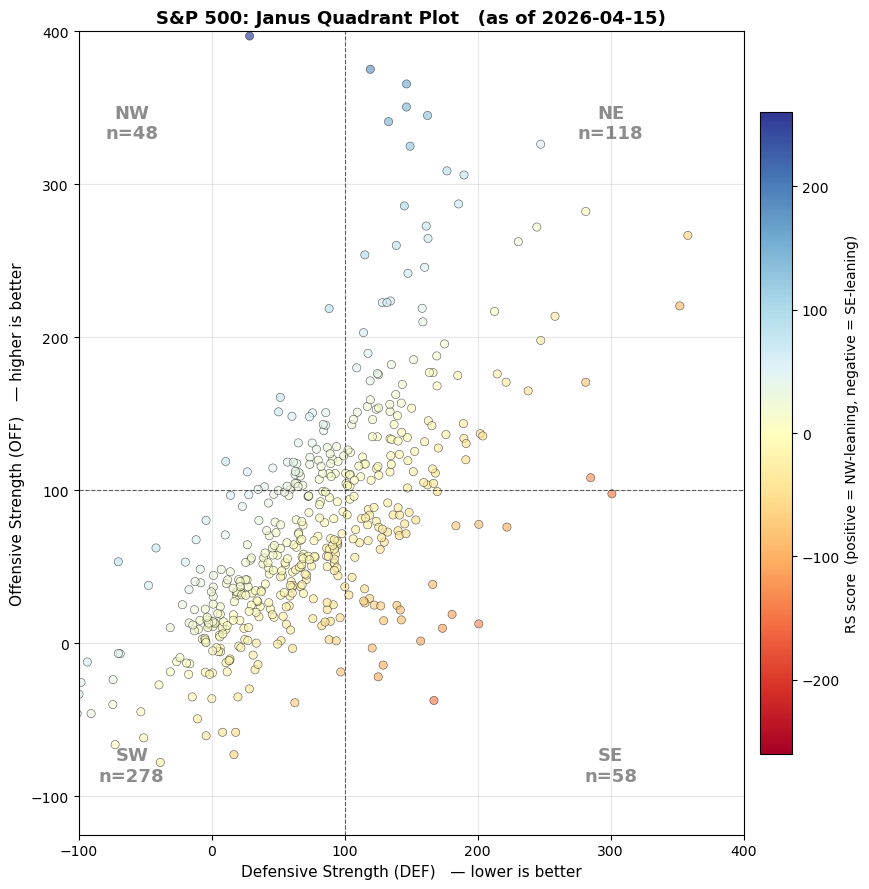


  S&P 500 quadrant counts (as of 2026-04-15):
    NW:   48  (  9.6%)
    NE:  118  ( 23.5%)
    SW:  278  ( 55.4%)
    SE:   58  ( 11.6%)
    Total classified: 502


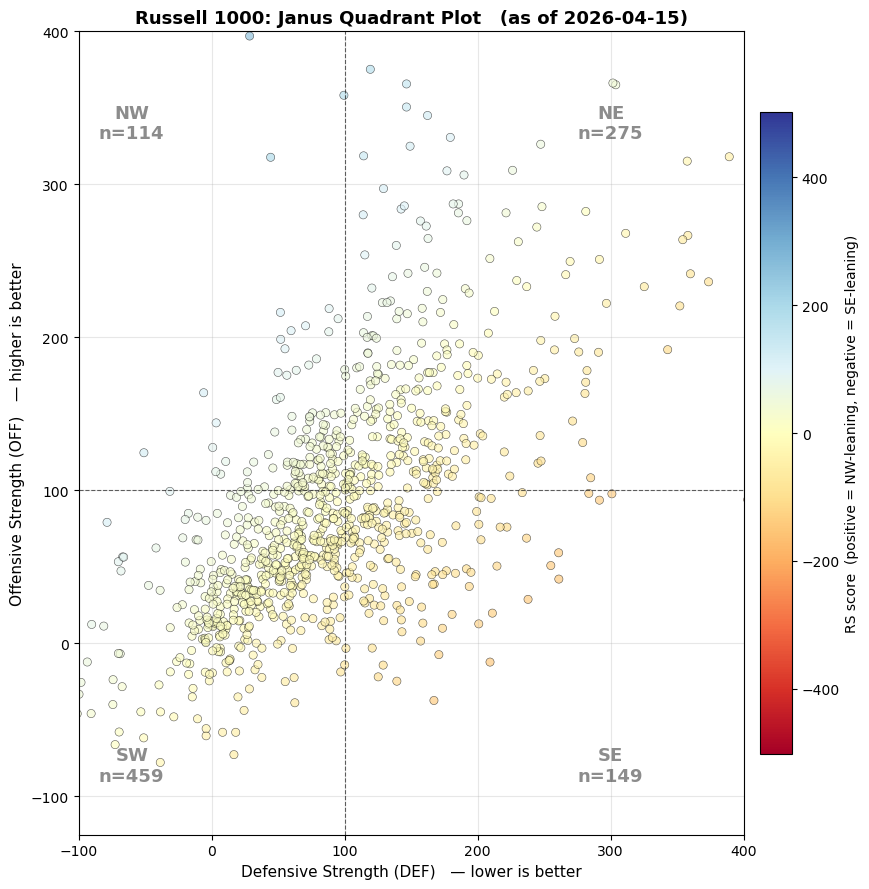


  Russell 1000 quadrant counts (as of 2026-04-15):
    NW:  114  ( 11.4%)
    NE:  275  ( 27.6%)
    SW:  459  ( 46.0%)
    SE:  149  ( 14.9%)
    Total classified: 997


In [10]:
def plot_janus_quadrant(off_matrix, def_matrix, rs_matrix,
                        universe_label, snapshot_date=None):
    """
    Janus quadrant scatter: OFF on Y-axis, DEF on X-axis, one point per stock.
    Points are colored by RS score using a diverging blue→red colormap.
    Matches the style of the reference Janus notebook (100 cross-hairs, quadrant labels).
    """
    if snapshot_date is None:
        snapshot_date = off_matrix.dropna(how='all').index[-1]

    off_row = off_matrix.loc[snapshot_date]
    def_row = def_matrix.loc[snapshot_date]
    rs_row  = rs_matrix.loc[snapshot_date]
    quad_row = assign_quadrants(off_row, def_row)

    # Filter to valid rows
    valid = off_row.notna() & def_row.notna()
    off_v = off_row[valid]
    def_v = def_row[valid]
    rs_v  = rs_row[valid]
    quad_v = quad_row[valid]

    fig, ax = plt.subplots(figsize=(9, 9))

    # Color by RS: blue (high RS, NW) → red (low RS, SE)
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    rs_abs_max = max(abs(rs_v.min()), abs(rs_v.max()), 50)
    norm = mcolors.TwoSlopeNorm(vmin=-rs_abs_max, vcenter=0, vmax=rs_abs_max)
    cmap = cm.get_cmap('RdYlBu')   # red-yellow-blue diverging
    colors = cmap(norm(rs_v.values))

    ax.scatter(def_v, off_v, c=colors, alpha=0.65, s=35, edgecolors='black',
               linewidths=0.4)

    # Quadrant cross-hairs at 100
    ax.axvline(100, linestyle='--', color='black', linewidth=0.8, alpha=0.6)
    ax.axhline(100, linestyle='--', color='black', linewidth=0.8, alpha=0.6)

    # Axis limits matching the reference Janus notebook style
    ax.set_xlim(-100, 400)
    ax.set_ylim(-125, 400)

    ax.set_xlabel('Defensive Strength (DEF)   — lower is better', fontsize=11)
    ax.set_ylabel('Offensive Strength (OFF)   — higher is better', fontsize=11)
    ax.set_title(f'{universe_label}: Janus Quadrant Plot   '
                 f'(as of {snapshot_date.strftime("%Y-%m-%d")})',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Quadrant labels + counts
    counts = quad_v.value_counts().reindex(['NW', 'NE', 'SW', 'SE'], fill_value=0)
    label_positions = {'NE': (300, 330), 'NW': (-60, 330),
                       'SW': (-60, -90),  'SE': (300, -90)}
    for label, (x, y) in label_positions.items():
        ax.text(x, y, f'{label}\nn={counts[label]}', fontsize=13, alpha=0.45,
                ha='center', fontweight='bold')

    # Colorbar for RS
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('RS score  (positive = NW-leaning, negative = SE-leaning)',
                    fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print quadrant counts table
    print(f"\n  {universe_label} quadrant counts (as of {snapshot_date.date()}):")
    total = counts.sum()
    for q in ['NW', 'NE', 'SW', 'SE']:
        pct = counts[q] / total * 100 if total > 0 else 0
        print(f"    {q}: {counts[q]:4d}  ({pct:5.1f}%)")
    print(f"    Total classified: {total}")


# -------- SPX quadrant scatter --------
plot_janus_quadrant(spx_off, spx_def, spx_rs, 'S&P 500')

# -------- R1K quadrant scatter --------
plot_janus_quadrant(r1k_off, r1k_def, r1k_rs, 'Russell 1000')

---
### 10.2 5-Day Rebalance Backtest: NW vs SE Baskets

At each 5-trading-day rebalance, we re-score every stock's Janus OFF/DEF and re-assign
quadrants. Two equal-weight baskets are held long until the next rebalance:

- **NW basket**: all stocks currently classified NW (strong offense + strong defense)
- **SE basket**: all stocks currently classified SE (weak offense + weak defense)

Both baskets are held **long**. The comparative strength line $NW / SE$ is the
cumulative ratio of the two equity curves — when it trends up, NW is outpacing SE,
which is the expected behavior if the Janus ranking is working.

In [11]:
def run_janus_quadrant_screen(close_prices, off_matrix, def_matrix,
                              rebal_period=5):
    """
    5-day rebalance backtest: re-score every stock, assign NW/NE/SW/SE quadrants,
    hold equal-weight NW and SE baskets long until the next rebalance.
    
    Returns a dict:
      'nw_returns'  : Series of daily NW basket returns
      'se_returns'  : Series of daily SE basket returns
      'ew_returns'  : Series of daily benchmark EW returns (universe-wide)
      'nw_members'  : dict rebal_date → list of NW tickers
      'se_members'  : dict rebal_date → list of SE tickers
      'all_quadrants': DataFrame of quadrant assignments at each rebal date
      'rebal_dates' : list of rebalance datetimes
    """
    dates = close_prices.index
    daily_rets = close_prices.pct_change()

    first_valid = off_matrix.dropna(how='all').index[0]
    valid_dates = dates[dates >= first_valid]
    rebal_dates = valid_dates[::rebal_period]

    nw_out, se_out, ew_out = {}, {}, {}
    nw_members, se_members = {}, {}
    quad_records = []

    for i in range(len(rebal_dates)):
        reb = rebal_dates[i]
        nxt = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else valid_dates[-1]
        fwd_mask = (dates > reb) & (dates <= nxt)
        fwd_dates = dates[fwd_mask]
        if len(fwd_dates) == 0:
            continue

        # Assign quadrants at rebalance date
        if reb not in off_matrix.index:
            continue
        off_row = off_matrix.loc[reb]
        def_row = def_matrix.loc[reb]
        quads = assign_quadrants(off_row, def_row)

        # Record the full quadrant snapshot
        quad_records.append(pd.Series(quads, name=reb))

        # Build NW and SE baskets
        nw_stocks = quads[quads == 'NW'].index.tolist()
        se_stocks = quads[quads == 'SE'].index.tolist()
        all_stocks = quads.dropna().index.tolist()

        nw_members[reb] = nw_stocks
        se_members[reb] = se_stocks

        # Daily forward returns — equal-weight average across basket
        nw_cols = [c for c in nw_stocks if c in daily_rets.columns]
        se_cols = [c for c in se_stocks if c in daily_rets.columns]
        ew_cols = [c for c in all_stocks if c in daily_rets.columns]

        nw_rets = (daily_rets.loc[fwd_dates, nw_cols].mean(axis=1)
                   if nw_cols else pd.Series(0.0, index=fwd_dates))
        se_rets = (daily_rets.loc[fwd_dates, se_cols].mean(axis=1)
                   if se_cols else pd.Series(0.0, index=fwd_dates))
        ew_rets = (daily_rets.loc[fwd_dates, ew_cols].mean(axis=1)
                   if ew_cols else pd.Series(0.0, index=fwd_dates))

        for dt in fwd_dates:
            nw_out[dt] = nw_rets.loc[dt]
            se_out[dt] = se_rets.loc[dt]
            ew_out[dt] = ew_rets.loc[dt]

    all_quadrants = pd.concat(quad_records, axis=1).T if quad_records else pd.DataFrame()

    return {
        'nw_returns':    pd.Series(nw_out).sort_index(),
        'se_returns':    pd.Series(se_out).sort_index(),
        'ew_returns':    pd.Series(ew_out).sort_index(),
        'nw_members':    nw_members,
        'se_members':    se_members,
        'all_quadrants': all_quadrants,
        'rebal_dates':   list(rebal_dates),
    }


def build_janus_equity(backtest_output):
    """
    Build equity curves: NW long, SE long, EW benchmark, and the comparative
    strength ratio NW/SE. Each curve starts at 1.0.
    """
    nw = backtest_output['nw_returns']
    se = backtest_output['se_returns']
    ew = backtest_output['ew_returns']

    nw_eq = (1 + nw).cumprod()
    se_eq = (1 + se).cumprod()
    ew_eq = (1 + ew).cumprod()

    df = pd.DataFrame({
        'NW_long':      nw_eq,
        'SE_long':      se_eq,
        'EW_benchmark': ew_eq,
    }).dropna()

    # Comparative strength: NW / SE
    # Rising = NW outperforming SE, falling = SE outperforming NW
    df['NW_div_SE'] = df['NW_long'] / df['SE_long']

    # Also relative to benchmark for context
    df['NW_vs_EW'] = df['NW_long'] / df['EW_benchmark']
    df['SE_vs_EW'] = df['SE_long'] / df['EW_benchmark']
    return df


# -------- Run the Janus quadrant backtest --------
print("=" * 70)
print("  JANUS QUADRANT BACKTEST")
print("=" * 70)

print("\n[1/2] S&P 500…")
spx_janus_bt = run_janus_quadrant_screen(spx_prices, spx_off, spx_def, REBAL_PERIOD)
spx_janus_eq = build_janus_equity(spx_janus_bt)
print(f"  Rebalances: {len(spx_janus_bt['rebal_dates'])}  "
      f"| Equity curve days: {len(spx_janus_eq)}")

# Most recent NW/SE sizes
last_reb_spx = max(spx_janus_bt['nw_members'].keys())
print(f"  Most recent rebalance: {last_reb_spx.date()}")
print(f"    NW: {len(spx_janus_bt['nw_members'][last_reb_spx]):3d} stocks  "
      f"| SE: {len(spx_janus_bt['se_members'][last_reb_spx]):3d} stocks")

print("\n[2/2] Russell 1000…")
r1k_janus_bt = run_janus_quadrant_screen(r1k_prices, r1k_off, r1k_def, REBAL_PERIOD)
r1k_janus_eq = build_janus_equity(r1k_janus_bt)
print(f"  Rebalances: {len(r1k_janus_bt['rebal_dates'])}  "
      f"| Equity curve days: {len(r1k_janus_eq)}")

last_reb_r1k = max(r1k_janus_bt['nw_members'].keys())
print(f"  Most recent rebalance: {last_reb_r1k.date()}")
print(f"    NW: {len(r1k_janus_bt['nw_members'][last_reb_r1k]):3d} stocks  "
      f"| SE: {len(r1k_janus_bt['se_members'][last_reb_r1k]):3d} stocks")

  JANUS QUADRANT BACKTEST

[1/2] S&P 500…
  Rebalances: 176  | Equity curve days: 876
  Most recent rebalance: 2026-04-14
    NW:  57 stocks  | SE:  60 stocks

[2/2] Russell 1000…
  Rebalances: 176  | Equity curve days: 876
  Most recent rebalance: 2026-04-14
    NW: 138 stocks  | SE: 149 stocks


  Rebalances: 176  | Equity curve days: 876
  Most recent rebalance: 2026-04-14
    NW:  57 stocks  | SE:  60 stocks

[2/2] Russell 1000…


  Rebalances: 176  | Equity curve days: 876
  Most recent rebalance: 2026-04-14
    NW: 138 stocks  | SE: 149 stocks


---
### 10.3 Equity Curves & Comparative Strength

Two-panel plot per universe:

**Top panel (absolute equity curves):**
- NW long — the top-quality basket (strong offense + strong defense)
- SE long — the bottom-quality basket (weak offense + weak defense)
- EW benchmark — full universe equal-weight for context

**Bottom panel (comparative strength, NW / SE):**
- When this ratio rises, NW is compounding faster than SE → Janus signal is separating
- Flat or declining ratio means the quadrant ranking is not producing a spread
- A fundamentally healthy Janus signal should show a steadily rising `NW / SE` line

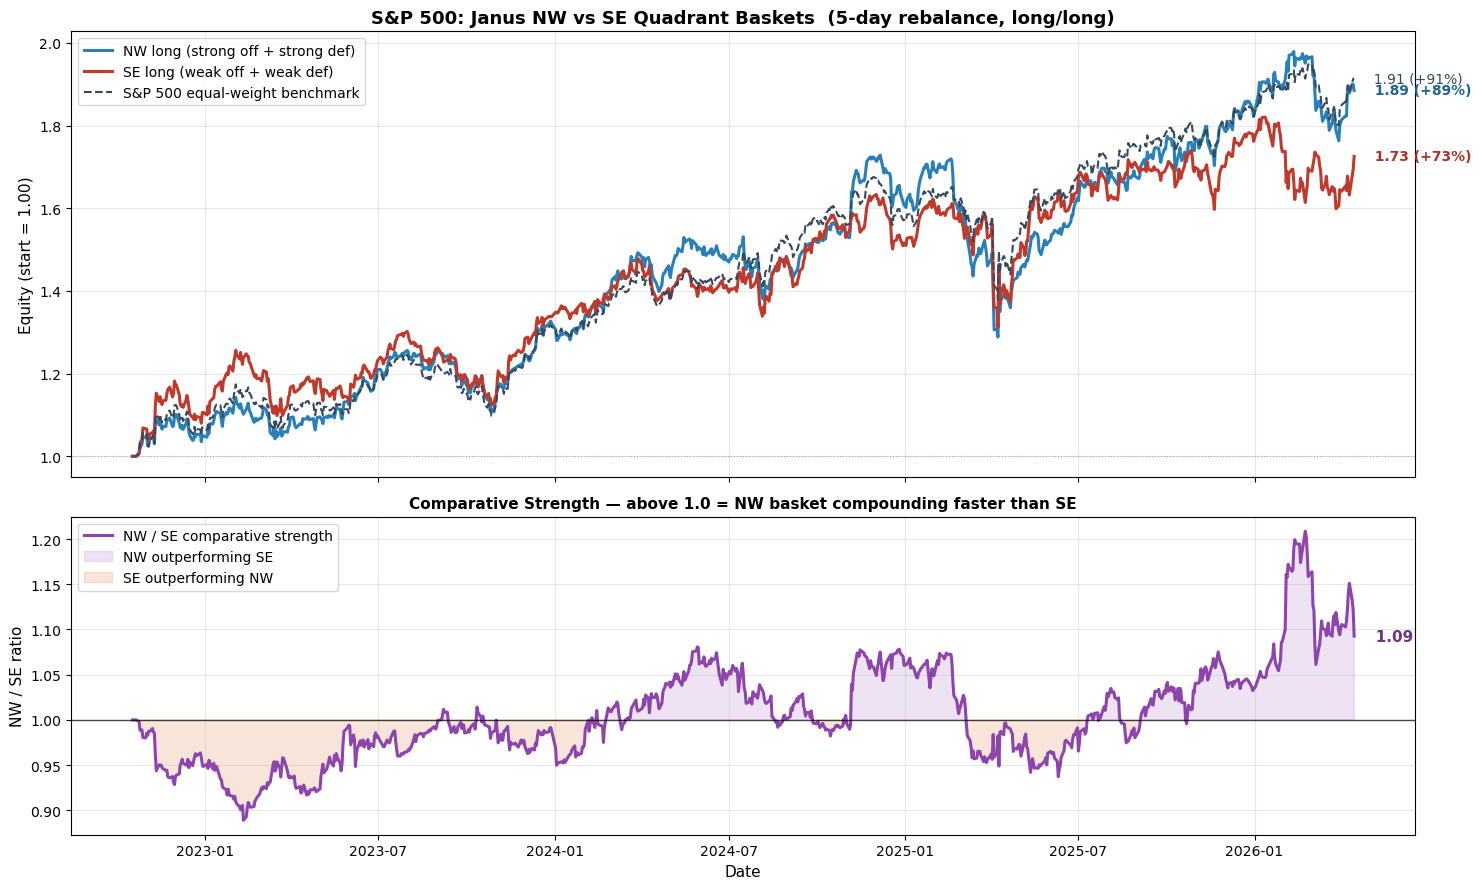

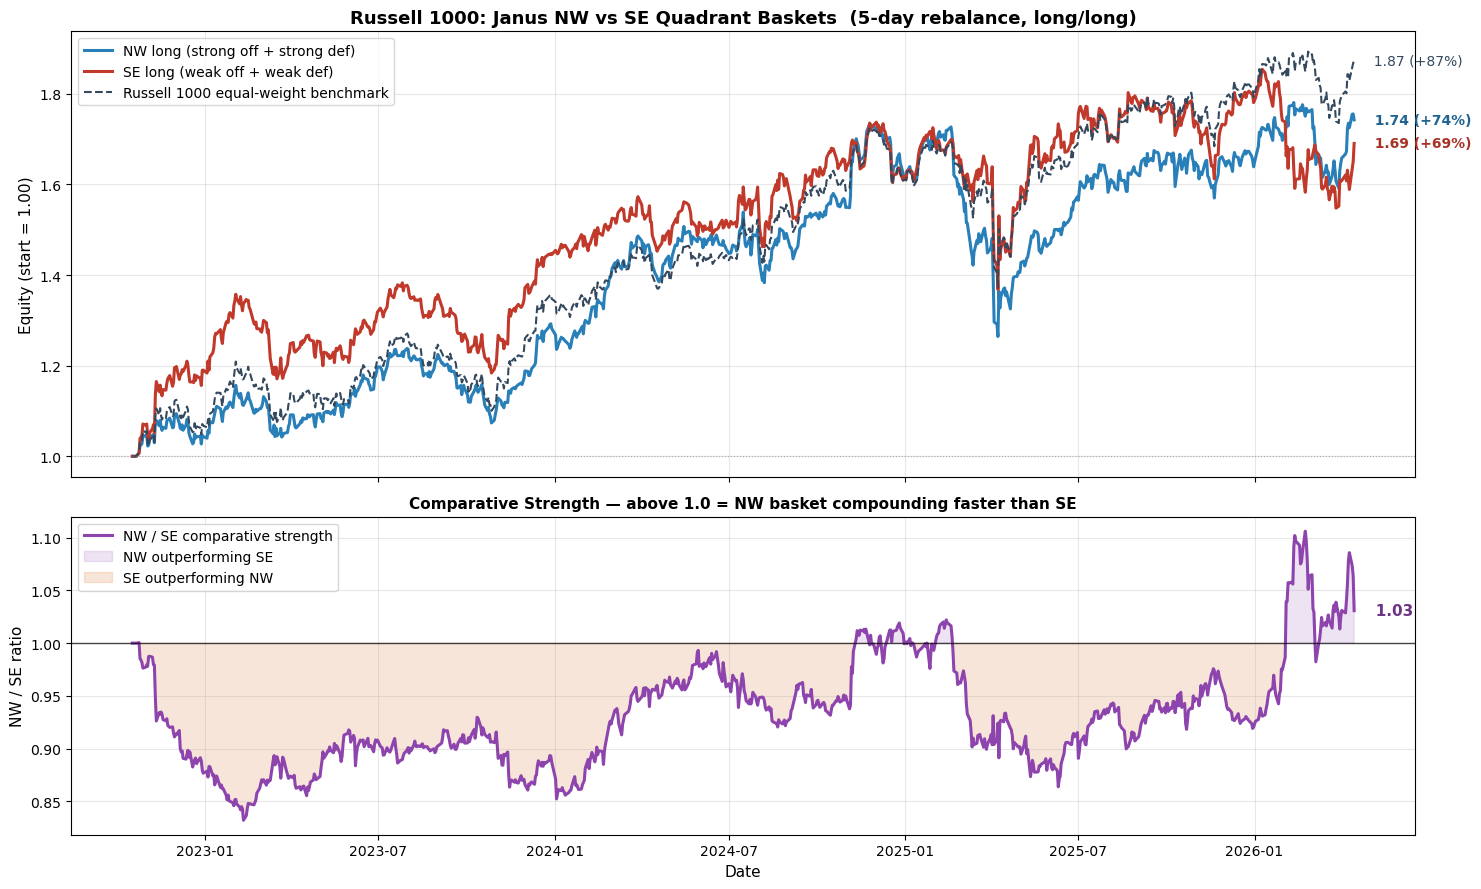

In [12]:
def plot_janus_equity(eq_df, universe_label):
    """
    Two-panel plot:
      Top:    NW long, SE long, EW benchmark — absolute equity curves
      Bottom: NW / SE comparative strength ratio (long-only spread)
    """
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                              gridspec_kw={'height_ratios': [1.4, 1]})

    # ---------- Panel 1: Absolute equity curves ----------
    ax = axes[0]
    ax.plot(eq_df.index, eq_df['NW_long'],
            label='NW long (strong off + strong def)',
            color='#2980b9', linewidth=2.2)
    ax.plot(eq_df.index, eq_df['SE_long'],
            label='SE long (weak off + weak def)',
            color='#c0392b', linewidth=2.2)
    ax.plot(eq_df.index, eq_df['EW_benchmark'],
            label=f'{universe_label} equal-weight benchmark',
            color='#34495e', linewidth=1.5, linestyle='--')

    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_ylabel('Equity (start = 1.00)', fontsize=11)
    ax.set_title(f'{universe_label}: Janus NW vs SE Quadrant Baskets  '
                 f'(5-day rebalance, long/long)',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Annotate final values on each line
    last_x = eq_df.index[-1]
    def _ann(y, text, color, bold=False):
        ax.annotate(f"  {text}", xy=(last_x, y), xytext=(8, 0),
                    textcoords='offset points', color=color, fontsize=10,
                    fontweight=('bold' if bold else 'normal'), va='center')

    _ann(eq_df['NW_long'].iloc[-1],
         f"{eq_df['NW_long'].iloc[-1]:.2f} "
         f"({(eq_df['NW_long'].iloc[-1]-1)*100:+.0f}%)",
         '#1f6391', bold=True)
    _ann(eq_df['SE_long'].iloc[-1],
         f"{eq_df['SE_long'].iloc[-1]:.2f} "
         f"({(eq_df['SE_long'].iloc[-1]-1)*100:+.0f}%)",
         '#a93226', bold=True)
    _ann(eq_df['EW_benchmark'].iloc[-1],
         f"{eq_df['EW_benchmark'].iloc[-1]:.2f} "
         f"({(eq_df['EW_benchmark'].iloc[-1]-1)*100:+.0f}%)",
         '#34495e')

    # ---------- Panel 2: NW / SE comparative strength ----------
    ax = axes[1]
    ax.plot(eq_df.index, eq_df['NW_div_SE'],
            color='#8e44ad', linewidth=2.2,
            label='NW / SE comparative strength')
    ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.7)
    ax.fill_between(eq_df.index, 1.0, eq_df['NW_div_SE'],
                     where=(eq_df['NW_div_SE'] >= 1.0),
                     alpha=0.15, color='#8e44ad', interpolate=True,
                     label='NW outperforming SE')
    ax.fill_between(eq_df.index, 1.0, eq_df['NW_div_SE'],
                     where=(eq_df['NW_div_SE'] < 1.0),
                     alpha=0.15, color='#d35400', interpolate=True,
                     label='SE outperforming NW')

    final_ratio = eq_df['NW_div_SE'].iloc[-1]
    ax.annotate(f"  {final_ratio:.2f}",
                xy=(last_x, final_ratio),
                xytext=(8, 0), textcoords='offset points',
                color='#6c3483', fontsize=11, fontweight='bold', va='center')

    ax.set_ylabel('NW / SE ratio', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_title('Comparative Strength — above 1.0 = NW basket compounding faster than SE',
                  fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# -------- Plot both universes --------
plot_janus_equity(spx_janus_eq, 'S&P 500')
plot_janus_equity(r1k_janus_eq, 'Russell 1000')

---
### 10.4 RS Spread Time-Series (MA9 with Slope Coloring)

Adapted from the reference Janus notebook. Each day we compute:

- The average RS score across all currently-NW stocks
- The average RS score across all currently-SE stocks
- Their difference (NW_avg_RS − SE_avg_RS)

A 9-day moving average smooths the spread. The MA9 line is colored by its daily slope
(green = rising, red = falling). Rising = the Janus ranking is getting more
discriminating (NW and SE are pulling apart); falling = the two baskets are converging.

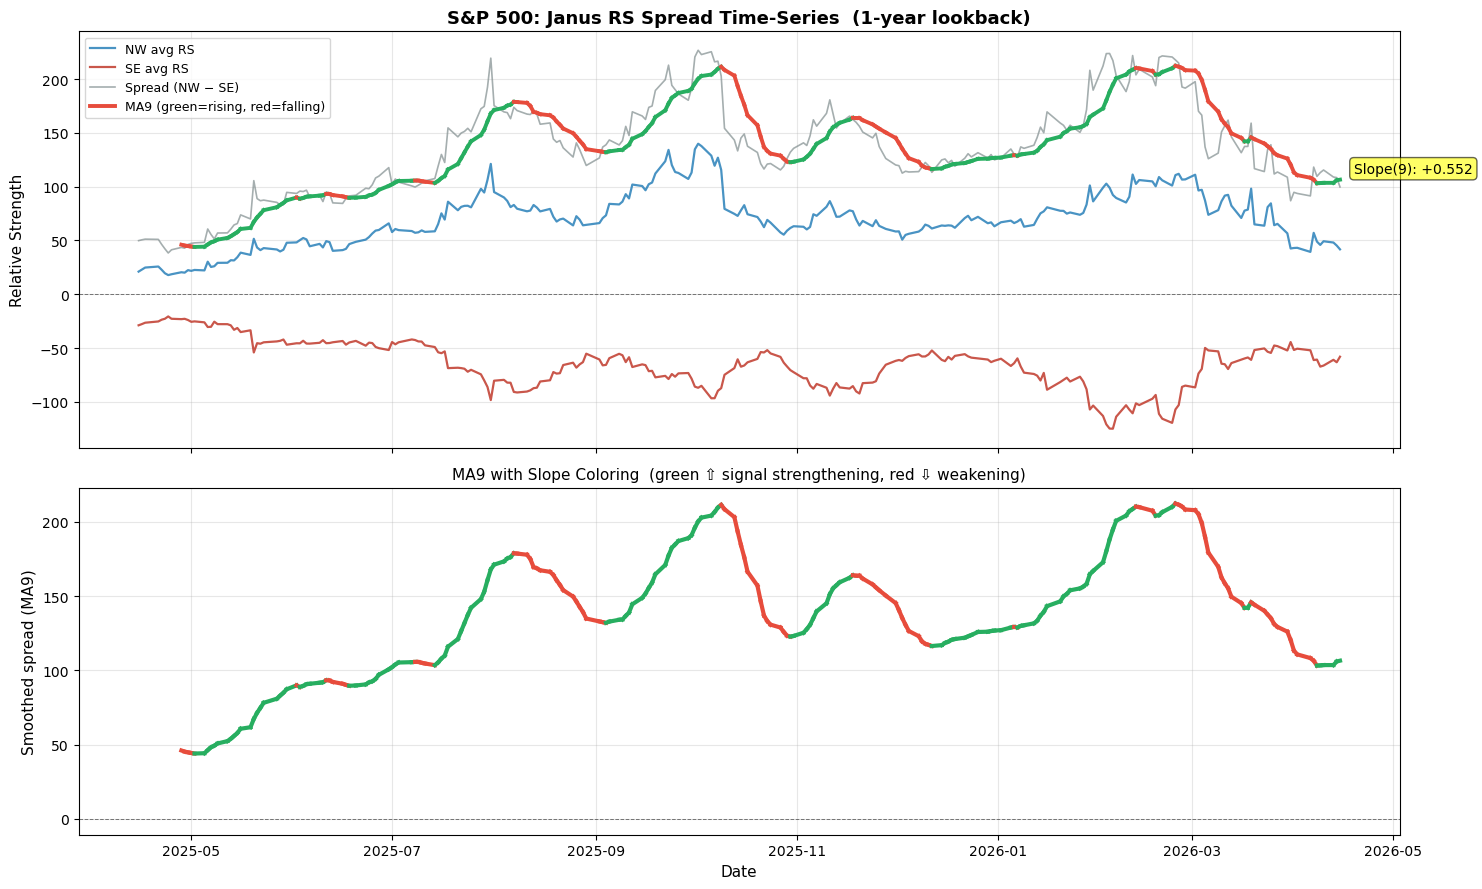


  S&P 500 — last 10 days of MA9 slope direction:
            MA_Spread   Slope Direction
Date                                   
2026-04-01    113.307 -7.1408   Falling
2026-04-02    110.749 -2.5578   Falling
2026-04-06    108.239 -2.5101   Falling
2026-04-07    106.447 -1.7918   Falling
2026-04-08    103.184 -3.2626   Falling
2026-04-09    103.330  0.1455    Rising
2026-04-10    103.537  0.2074    Rising
2026-04-13    103.553  0.0155    Rising
2026-04-14    105.944  2.3914    Rising
2026-04-15    106.497  0.5524    Rising


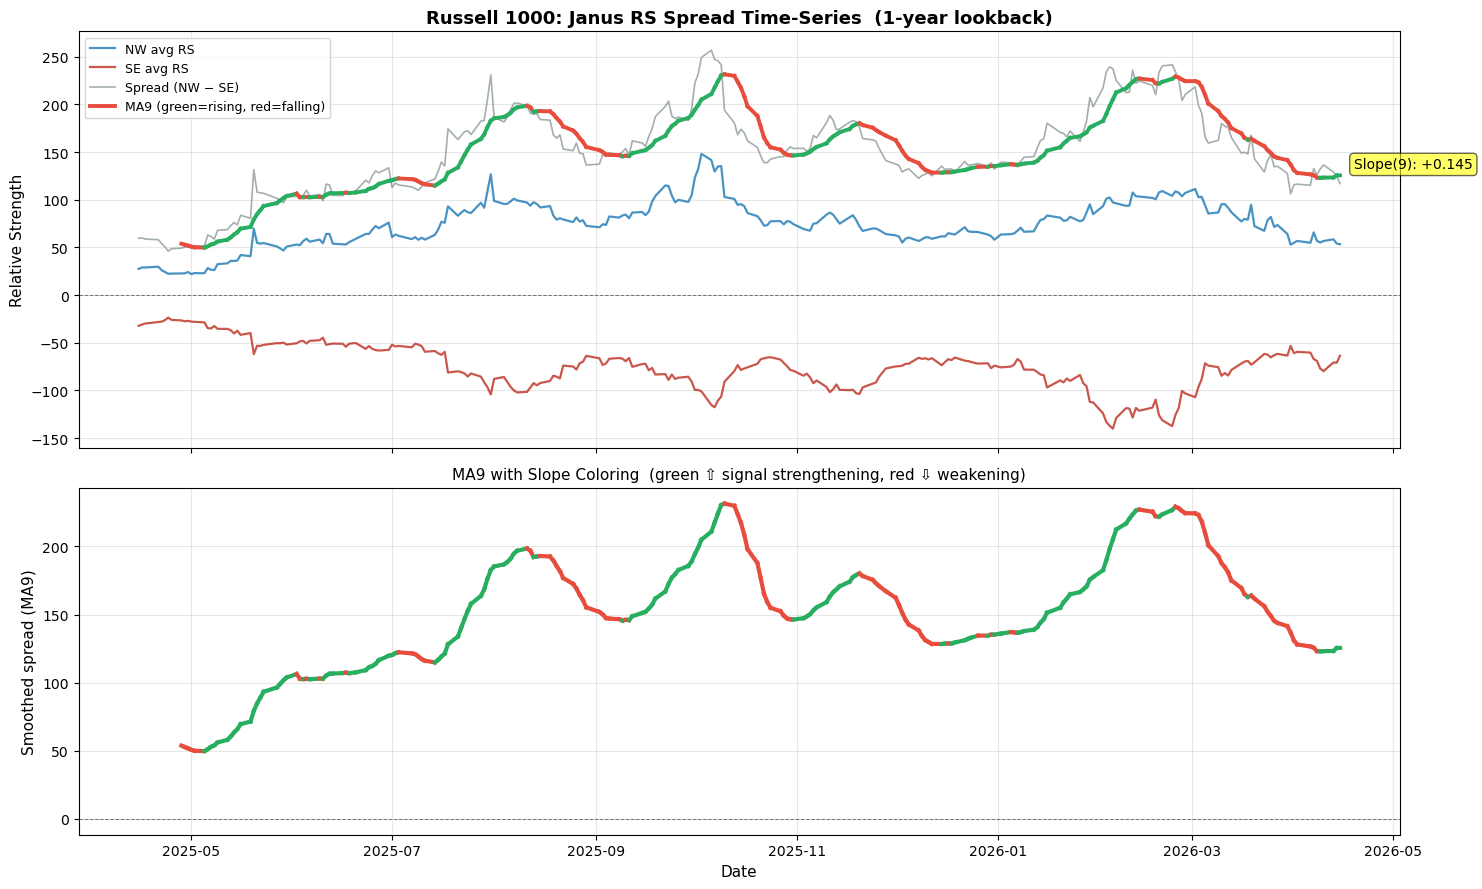


  Russell 1000 — last 10 days of MA9 slope direction:
            MA_Spread   Slope Direction
Date                                   
2026-04-01    131.028 -5.7781   Falling
2026-04-02    128.087 -2.9406   Falling
2026-04-06    126.537 -1.5509   Falling
2026-04-07    125.600 -0.9365   Falling
2026-04-08    123.238 -2.3623   Falling
2026-04-09    122.979 -0.2592   Falling
2026-04-10    123.129  0.1499    Rising
2026-04-13    123.293  0.1645    Rising
2026-04-14    125.385  2.0920    Rising
2026-04-15    125.530  0.1454    Rising


In [13]:
def plot_rs_spread_timeseries(off_matrix, def_matrix, rs_matrix,
                               universe_label, ma_window=9, lookback_years=1):
    """
    Replicates the reference Janus notebook's RS-spread-time-series visualization.
    For each date, compute:
      - Average RS across stocks currently classified NW
      - Average RS across stocks currently classified SE
      - Spread = NW_avg - SE_avg
    Smooth spread with a `ma_window`-day MA, color the MA line by its daily slope.
    """
    # Build quadrant matrix for every day
    quad_frame = pd.DataFrame(index=off_matrix.index, columns=off_matrix.columns,
                               dtype='object')
    # Vectorized quadrant assignment per row (keeps NaN where OFF/DEF are NaN)
    for i in range(len(off_matrix)):
        off_row = off_matrix.iloc[i]
        def_row = def_matrix.iloc[i]
        quad_frame.iloc[i] = assign_quadrants(off_row, def_row)

    # NW/SE average RS time-series
    nw_avg_ts = rs_matrix.where(quad_frame == 'NW').mean(axis=1)
    se_avg_ts = rs_matrix.where(quad_frame == 'SE').mean(axis=1)
    spread = nw_avg_ts - se_avg_ts

    # Restrict to lookback window (default 1 year, matching reference notebook)
    end = rs_matrix.dropna(how='all').index[-1]
    start = end - pd.DateOffset(years=lookback_years)
    nw_avg_ts = nw_avg_ts.loc[start:end]
    se_avg_ts = se_avg_ts.loc[start:end]
    spread = spread.loc[start:end]

    # MA9-smoothed spread and its slope
    ma = spread.rolling(window=ma_window).mean()
    slope = ma.diff()
    current_slope = slope.iloc[-1]

    # ---------- Combined plot ----------
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                              gridspec_kw={'height_ratios': [1.2, 1]})

    # Panel 1: NW avg, SE avg, raw spread
    ax = axes[0]
    ax.plot(nw_avg_ts.index, nw_avg_ts.values,
             label='NW avg RS', color='#2980b9', linewidth=1.6, alpha=0.85)
    ax.plot(se_avg_ts.index, se_avg_ts.values,
             label='SE avg RS', color='#c0392b', linewidth=1.6, alpha=0.85)
    ax.plot(spread.index, spread.values,
             label='Spread (NW − SE)', color='#7f8c8d', linewidth=1.2, alpha=0.7)

    # Overlay MA9 with slope-based coloring
    ma_valid = ma.dropna()
    if len(ma_valid) > 1:
        for i in range(1, len(ma_valid)):
            x = ma_valid.index[i-1:i+1]
            y = ma_valid.iloc[i-1:i+1]
            color = '#27ae60' if slope.loc[ma_valid.index[i]] >= 0 else '#e74c3c'
            ax.plot(x, y, color=color, linewidth=2.8,
                     label=(f'MA{ma_window} (green=rising, red=falling)'
                             if i == 1 else None))

    ax.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_ylabel('Relative Strength', fontsize=11)
    ax.set_title(f'{universe_label}: Janus RS Spread Time-Series  '
                  f'({lookback_years}-year lookback)',
                  fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate current slope at the right edge
    if not ma_valid.empty:
        ax.annotate(f'Slope({ma_window}): {current_slope:+.3f}',
                     xy=(ma_valid.index[-1], ma_valid.iloc[-1]),
                     xytext=(10, 5), textcoords='offset points',
                     fontsize=10,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.6))

    # Panel 2: MA-only plot with slope coloring — matches reference "Script 5" style
    ax = axes[1]
    if len(ma_valid) > 1:
        for i in range(1, len(ma_valid)):
            x = ma_valid.index[i-1:i+1]
            y = ma_valid.iloc[i-1:i+1]
            color = '#27ae60' if slope.loc[ma_valid.index[i]] >= 0 else '#e74c3c'
            ax.plot(x, y, color=color, linewidth=3.0)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_ylabel(f'Smoothed spread (MA{ma_window})', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_title(f'MA{ma_window} with Slope Coloring  '
                  f'(green ⇧ signal strengthening, red ⇩ weakening)',
                  fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Direction summary for recent days
    recent = pd.DataFrame({
        'MA_Spread': ma.tail(10).round(3),
        'Slope': slope.tail(10).round(4),
        'Direction': np.where(slope.tail(10) >= 0, 'Rising', 'Falling'),
    })
    print(f"\n  {universe_label} — last 10 days of MA{ma_window} slope direction:")
    print(recent.to_string())


# -------- Plot RS spread for both universes --------
plot_rs_spread_timeseries(spx_off, spx_def, spx_rs, 'S&P 500')
plot_rs_spread_timeseries(r1k_off, r1k_def, r1k_rs, 'Russell 1000')

---
### 10.5 Current Janus Watchlists

Two snapshots per universe:

- **Rebalance-date watchlist** — NW and SE constituents as of the most recent 5-day
  rebalance. These are the names driving the equity curves above from that date forward.
- **Live watchlist** — NW and SE classifications computed on the most recent available
  close. This is the actionable list for discretionary trading.

Each table shows: Rank (by RS descending for NW, ascending for SE), Ticker, Close, OFF,
DEF, RS, and the same 21/63/126-day returns as the CRS watchlist for quick cross-reference.

In [14]:
def build_janus_watchlist(close_prices, backtest_output, off_matrix, def_matrix,
                           rs_matrix, universe_label):
    """
    Build NW and SE watchlists for both the most recent rebalance date
    and the live close. Each row includes OFF, DEF, RS, and trailing returns.
    """
    last_reb  = max(backtest_output['nw_members'].keys())
    live_date = close_prices.index[-1]

    rebal_nw = backtest_output['nw_members'][last_reb]
    rebal_se = backtest_output['se_members'][last_reb]

    # Live quadrants
    live_off = off_matrix.loc[live_date]
    live_def = def_matrix.loc[live_date]
    live_quads = assign_quadrants(live_off, live_def)
    live_nw = live_quads[live_quads == 'NW'].index.tolist()
    live_se = live_quads[live_quads == 'SE'].index.tolist()

    def build_row(t, ranking_date, quadrant_label):
        if t not in close_prices.columns:
            return None
        p = close_prices[t]
        if ranking_date not in p.index or pd.isna(p.loc[ranking_date]):
            return None
        p_now = p.loc[ranking_date]
        idx = p.index.get_loc(ranking_date)

        def pct_lb(lb):
            i0 = idx - lb
            if i0 < 0 or pd.isna(p.iloc[i0]):
                return np.nan
            return (p_now / p.iloc[i0] - 1) * 100

        off_val = off_matrix.loc[ranking_date, t] if t in off_matrix.columns else np.nan
        def_val = def_matrix.loc[ranking_date, t] if t in def_matrix.columns else np.nan
        rs_val  = rs_matrix.loc[ranking_date, t]  if t in rs_matrix.columns  else np.nan

        return {
            'Ticker':  t,
            'Close':   p_now,
            'OFF':     off_val,
            'DEF':     def_val,
            'RS':      rs_val,
            'Q':       quadrant_label,
            'Ret_21d':  pct_lb(21),
            'Ret_63d':  pct_lb(63),
            'Ret_126d': pct_lb(126),
        }

    def make_df(tickers, ranking_date, quadrant_label, sort_ascending):
        rows = [build_row(t, ranking_date, quadrant_label) for t in tickers]
        rows = [r for r in rows if r is not None]
        df = pd.DataFrame(rows)
        if len(df) == 0:
            return df
        df = df.sort_values('RS', ascending=sort_ascending).reset_index(drop=True)
        df.insert(0, 'Rank', range(1, len(df) + 1))
        return df

    return {
        'universe':       universe_label,
        'last_reb_date':  last_reb,
        'live_date':      live_date,
        'rebal_nw':  make_df(rebal_nw, last_reb, 'NW', sort_ascending=False),  # highest RS first
        'rebal_se':  make_df(rebal_se, last_reb, 'SE', sort_ascending=True),   # lowest RS first
        'live_nw':   make_df(live_nw,  live_date, 'NW', sort_ascending=False),
        'live_se':   make_df(live_se,  live_date, 'SE', sort_ascending=True),
    }


def display_janus_watchlist(wl):
    """Pretty-print a Janus watchlist with OFF/DEF/RS and trailing returns."""
    print("=" * 110)
    print(f"  {wl['universe']}  —  Janus Watchlists")
    print("=" * 110)
    print(f"  Rebalance-date snapshot:      {wl['last_reb_date'].date()}  "
          f"(NW={len(wl['rebal_nw'])}, SE={len(wl['rebal_se'])})")
    print(f"  Live snapshot (latest close): {wl['live_date'].date()}  "
          f"(NW={len(wl['live_nw'])}, SE={len(wl['live_se'])})")

    sections = [
        (f"NW (strong off + strong def) — rebalance {wl['last_reb_date'].date()}", wl['rebal_nw']),
        (f"SE (weak off + weak def) — rebalance {wl['last_reb_date'].date()}",     wl['rebal_se']),
        (f"NW (strong off + strong def) — live {wl['live_date'].date()}",          wl['live_nw']),
        (f"SE (weak off + weak def) — live {wl['live_date'].date()}",              wl['live_se']),
    ]
    for title, df in sections:
        print("\n" + "-" * 110)
        print(f"  {title}")
        print("-" * 110)
        if len(df) == 0:
            print("  (empty)")
            continue
        disp = df.copy()
        for c in ['Close']:
            if c in disp.columns:
                disp[c] = disp[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
        for c in ['OFF', 'DEF', 'RS']:
            if c in disp.columns:
                disp[c] = disp[c].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
        for c in ['Ret_21d', 'Ret_63d', 'Ret_126d']:
            if c in disp.columns:
                disp[c] = disp[c].map(lambda x: f"{x:+.1f}%" if pd.notna(x) else "—")
        # Show top 60 rows to keep output manageable
        if len(disp) > 60:
            print(disp.head(60).to_string(index=False))
            print(f"  ... ({len(disp) - 60} more rows)")
        else:
            print(disp.to_string(index=False))


# Build watchlists for both universes
print("Building Janus watchlists…\n")
spx_janus_wl = build_janus_watchlist(spx_prices, spx_janus_bt, spx_off, spx_def, spx_rs,
                                      'S&P 500')
r1k_janus_wl = build_janus_watchlist(r1k_prices, r1k_janus_bt, r1k_off, r1k_def, r1k_rs,
                                      'Russell 1000')

display_janus_watchlist(spx_janus_wl)
print("\n\n")
display_janus_watchlist(r1k_janus_wl)

Building Janus watchlists…

  S&P 500  —  Janus Watchlists
  Rebalance-date snapshot:      2026-04-14  (NW=57, SE=60)
  Live snapshot (latest close): 2026-04-15  (NW=48, SE=58)

--------------------------------------------------------------------------------------------------------------
  NW (strong off + strong def) — rebalance 2026-04-14
--------------------------------------------------------------------------------------------------------------
 Rank Ticker  Close   OFF  DEF    RS  Q Ret_21d Ret_63d Ret_126d
    1   LITE 852.79 420.2 19.2 283.5 NW  +37.0% +150.9%  +470.0%
    2    GEV 987.50 232.4 85.4 103.9 NW  +22.7%  +54.4%   +63.6%
    3   DELL 184.51 190.6 52.6  97.6 NW  +21.7%  +53.8%   +23.5%
    4   SATS 130.47 163.2 52.8  78.1 NW  +20.4%   +3.5%   +76.3%
    5    SLB  51.49 112.5  8.0  73.9 NW  +15.1%  +14.7%   +64.6%
    6   ODFL 210.41 164.3 61.8  72.5 NW  +16.4%  +21.4%   +57.2%
    7   JBHT 229.61 112.2 14.9  68.8 NW  +14.7%  +11.5%   +68.3%
    8    NUE 190.04 113.4 

---
### 10.6 CRS ↔ Janus Overlap Analysis

CRS and Janus answer different questions:

- **CRS** ranks stocks against their peers within the universe (cross-sectional).
- **Janus** measures stocks against an external benchmark (SPY), separately on
  benchmark up-days and down-days.

A **2×2 contingency table** shows how the two systems overlap on the current
snapshot. The interesting cases are the **disagreements**:

- **CRS D1 ∩ Janus SE** — top-decile CRS momentum, but weak OFF *and* weak DEF
  vs SPY. These are leaders in a weak universe or names where the peer-relative
  ranking exceeds their standalone benchmark-relative performance.
- **CRS D10 ∩ Janus NW** — bottom-decile CRS momentum, but strong OFF + strong DEF
  vs SPY. These are laggards relative to peers but still solid vs market —
  typically slow-moving quality names temporarily out of favor.

The **agreement cases** are the highest-conviction long and short candidates:

- **CRS D1 ∩ Janus NW** — top on both measures (strongest conviction long)
- **CRS D10 ∩ Janus SE** — bottom on both measures (strongest conviction avoid/short)

In [15]:
def compute_crs_janus_overlap(crs_wl, janus_wl, off_matrix, def_matrix, rs_matrix,
                               close_prices, snapshot='live'):
    """
    Build a 2x2 contingency table of CRS decile membership vs Janus quadrant.
    Also produces detail lists for each intersection.
    
    snapshot: 'live' uses the live-close watchlists; 'rebal' uses rebalance-date.
    """
    if snapshot == 'live':
        crs_d1   = set(crs_wl['live_d1']['Ticker'].tolist())
        crs_d10  = set(crs_wl['live_d10']['Ticker'].tolist())
        janus_nw = set(janus_wl['live_nw']['Ticker'].tolist())
        janus_se = set(janus_wl['live_se']['Ticker'].tolist())
        ref_date = janus_wl['live_date']
    else:
        crs_d1   = set(crs_wl['rebal_d1']['Ticker'].tolist())
        crs_d10  = set(crs_wl['rebal_d10']['Ticker'].tolist())
        janus_nw = set(janus_wl['rebal_nw']['Ticker'].tolist())
        janus_se = set(janus_wl['rebal_se']['Ticker'].tolist())
        ref_date = janus_wl['last_reb_date']

    # Intersections
    d1_nw   = sorted(crs_d1  & janus_nw)
    d1_se   = sorted(crs_d1  & janus_se)
    d10_nw  = sorted(crs_d10 & janus_nw)
    d10_se  = sorted(crs_d10 & janus_se)

    # Names in CRS D1/D10 but classified neither NW nor SE (i.e., NE or SW)
    d1_other  = sorted(crs_d1  - janus_nw - janus_se)
    d10_other = sorted(crs_d10 - janus_nw - janus_se)

    # Build a detail table for a given ticker list
    def detail_table(tickers, ref_date):
        rows = []
        for t in tickers:
            if t not in close_prices.columns:
                continue
            p = close_prices[t]
            if ref_date not in p.index or pd.isna(p.loc[ref_date]):
                continue
            p_now = p.loc[ref_date]
            idx = p.index.get_loc(ref_date)
            def pct_lb(lb):
                i0 = idx - lb
                if i0 < 0 or pd.isna(p.iloc[i0]):
                    return np.nan
                return (p_now / p.iloc[i0] - 1) * 100
            rows.append({
                'Ticker': t,
                'Close': p_now,
                'OFF': off_matrix.loc[ref_date, t] if t in off_matrix.columns else np.nan,
                'DEF': def_matrix.loc[ref_date, t] if t in def_matrix.columns else np.nan,
                'RS':  rs_matrix.loc[ref_date, t]  if t in rs_matrix.columns  else np.nan,
                'Ret_21d':  pct_lb(21),
                'Ret_63d':  pct_lb(63),
                'Ret_126d': pct_lb(126),
            })
        df = pd.DataFrame(rows)
        if len(df):
            df = df.sort_values('RS', ascending=False).reset_index(drop=True)
        return df

    return {
        'snapshot':   snapshot,
        'ref_date':   ref_date,
        'crs_d1_n':   len(crs_d1),
        'crs_d10_n':  len(crs_d10),
        'janus_nw_n': len(janus_nw),
        'janus_se_n': len(janus_se),
        'd1_nw':      detail_table(d1_nw,   ref_date),
        'd1_se':      detail_table(d1_se,   ref_date),
        'd10_nw':     detail_table(d10_nw,  ref_date),
        'd10_se':     detail_table(d10_se,  ref_date),
        'd1_other':   detail_table(d1_other,  ref_date),
        'd10_other':  detail_table(d10_other, ref_date),
    }


def display_overlap(overlap, universe_label):
    """Print the contingency table and the four intersection detail tables."""
    print("=" * 110)
    print(f"  {universe_label}  —  CRS × Janus Overlap  "
          f"({overlap['snapshot']} snapshot, {overlap['ref_date'].date()})")
    print("=" * 110)

    # 2×2 contingency table
    n_d1_nw   = len(overlap['d1_nw'])
    n_d1_se   = len(overlap['d1_se'])
    n_d10_nw  = len(overlap['d10_nw'])
    n_d10_se  = len(overlap['d10_se'])
    n_d1_other  = len(overlap['d1_other'])
    n_d10_other = len(overlap['d10_other'])

    print(f"\n  CRS D1 total:   {overlap['crs_d1_n']:3d}  "
          f"(Janus NW {n_d1_nw}, SE {n_d1_se}, NE/SW {n_d1_other})")
    print(f"  CRS D10 total:  {overlap['crs_d10_n']:3d}  "
          f"(Janus NW {n_d10_nw}, SE {n_d10_se}, NE/SW {n_d10_other})")
    print(f"  Janus NW total: {overlap['janus_nw_n']:3d}")
    print(f"  Janus SE total: {overlap['janus_se_n']:3d}")

    print("\n  Contingency (counts):")
    print(f"  {'':12s} {'Janus NW':>10s} {'Janus SE':>10s} {'NE/SW':>10s}")
    print(f"  {'CRS D1':12s} {n_d1_nw:>10d} {n_d1_se:>10d} {n_d1_other:>10d}")
    print(f"  {'CRS D10':12s} {n_d10_nw:>10d} {n_d10_se:>10d} {n_d10_other:>10d}")

    # Display each intersection
    sections = [
        ("D1 ∩ NW — Highest-conviction longs (top CRS + strong Janus)",
         overlap['d1_nw']),
        ("D10 ∩ SE — Highest-conviction avoids (bottom CRS + weak Janus)",
         overlap['d10_se']),
        ("D1 ∩ SE — Disagreement: strong CRS but weak Janus (peer leader, bench laggard)",
         overlap['d1_se']),
        ("D10 ∩ NW — Disagreement: weak CRS but strong Janus (peer laggard, bench solid)",
         overlap['d10_nw']),
    ]
    for title, df in sections:
        print("\n" + "-" * 110)
        print(f"  {title}")
        print("-" * 110)
        if len(df) == 0:
            print("  (empty)")
            continue
        disp = df.copy()
        for c in ['Close']:
            if c in disp.columns:
                disp[c] = disp[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
        for c in ['OFF', 'DEF', 'RS']:
            if c in disp.columns:
                disp[c] = disp[c].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
        for c in ['Ret_21d', 'Ret_63d', 'Ret_126d']:
            if c in disp.columns:
                disp[c] = disp[c].map(lambda x: f"{x:+.1f}%" if pd.notna(x) else "—")
        print(disp.to_string(index=False))


# -------- Compute overlap for both universes (live snapshot) --------
print("Computing CRS × Janus overlap…\n")

spx_overlap = compute_crs_janus_overlap(spx_wl, spx_janus_wl,
                                          spx_off, spx_def, spx_rs,
                                          spx_prices, snapshot='live')
r1k_overlap = compute_crs_janus_overlap(r1k_wl, r1k_janus_wl,
                                          r1k_off, r1k_def, r1k_rs,
                                          r1k_prices, snapshot='live')

display_overlap(spx_overlap, 'S&P 500')
print("\n\n")
display_overlap(r1k_overlap, 'Russell 1000')

Computing CRS × Janus overlap…

  S&P 500  —  CRS × Janus Overlap  (live snapshot, 2026-04-15)

  CRS D1 total:    50  (Janus NW 12, SE 0, NE/SW 38)
  CRS D10 total:   51  (Janus NW 0, SE 28, NE/SW 23)
  Janus NW total:  48
  Janus SE total:  58

  Contingency (counts):
                 Janus NW   Janus SE      NE/SW
  CRS D1               12          0         38
  CRS D10               0         28         23

--------------------------------------------------------------------------------------------------------------
  D1 ∩ NW — Highest-conviction longs (top CRS + strong Janus)
--------------------------------------------------------------------------------------------------------------
Ticker  Close   OFF  DEF    RS Ret_21d Ret_63d Ret_126d
  LITE 824.01 396.9 28.6 260.5  +31.9% +128.0%  +413.2%
   GEV 985.92 218.8 88.4  92.3  +19.2%  +51.3%   +52.4%
  DELL 177.28 160.8 51.7  77.2  +13.2%  +48.8%   +16.5%
   SLB  52.42 118.9 10.6  76.6  +16.6%  +14.9%   +64.7%
  SATS 131.39 151.3 

In [16]:
# ----------------------------------------------------------
# Export Janus watchlists and overlap analysis to the same directory
# ----------------------------------------------------------
print(f"Exporting Janus outputs to: {OUTPUT_DIR}\n")


def export_janus_watchlist(wl, prefix):
    paths = []
    files = {
        f'{prefix}_JANUS_NW_rebal.csv': wl['rebal_nw'],
        f'{prefix}_JANUS_SE_rebal.csv': wl['rebal_se'],
        f'{prefix}_JANUS_NW_live.csv':  wl['live_nw'],
        f'{prefix}_JANUS_SE_live.csv':  wl['live_se'],
    }
    for fn, df in files.items():
        full = os.path.join(OUTPUT_DIR, fn)
        df.to_csv(full, index=False)
        paths.append(full)
        print(f"  [OK] {fn}  ({len(df)} rows)")
    return paths


def export_overlap(overlap, prefix):
    paths = []
    files = {
        f'{prefix}_OVERLAP_D1_NW.csv':  overlap['d1_nw'],
        f'{prefix}_OVERLAP_D1_SE.csv':  overlap['d1_se'],
        f'{prefix}_OVERLAP_D10_NW.csv': overlap['d10_nw'],
        f'{prefix}_OVERLAP_D10_SE.csv': overlap['d10_se'],
    }
    for fn, df in files.items():
        full = os.path.join(OUTPUT_DIR, fn)
        df.to_csv(full, index=False)
        paths.append(full)
        print(f"  [OK] {fn}  ({len(df)} rows)")
    return paths


print("S&P 500 Janus watchlists:")
export_janus_watchlist(spx_janus_wl, 'SPX')
print("\nS&P 500 CRS × Janus overlap:")
export_overlap(spx_overlap, 'SPX')

print("\nRussell 1000 Janus watchlists:")
export_janus_watchlist(r1k_janus_wl, 'R1K')
print("\nRussell 1000 CRS × Janus overlap:")
export_overlap(r1k_overlap, 'R1K')

# Also save the Janus equity curves
spx_janus_eq.to_csv(os.path.join(OUTPUT_DIR, 'SPX_JANUS_equity_curves.csv'))
r1k_janus_eq.to_csv(os.path.join(OUTPUT_DIR, 'R1K_JANUS_equity_curves.csv'))
print(f"\n  [OK] SPX_JANUS_equity_curves.csv  ({len(spx_janus_eq)} rows)")
print(f"  [OK] R1K_JANUS_equity_curves.csv  ({len(r1k_janus_eq)} rows)")

print(f"\nAll Janus outputs written to: {OUTPUT_DIR}")

Exporting Janus outputs to: /Users/scottmaragioglio/CRS_Quant/crs_screen_output

S&P 500 Janus watchlists:
  [OK] SPX_JANUS_NW_rebal.csv  (57 rows)
  [OK] SPX_JANUS_SE_rebal.csv  (60 rows)
  [OK] SPX_JANUS_NW_live.csv  (48 rows)
  [OK] SPX_JANUS_SE_live.csv  (58 rows)

S&P 500 CRS × Janus overlap:
  [OK] SPX_OVERLAP_D1_NW.csv  (12 rows)
  [OK] SPX_OVERLAP_D1_SE.csv  (0 rows)
  [OK] SPX_OVERLAP_D10_NW.csv  (0 rows)
  [OK] SPX_OVERLAP_D10_SE.csv  (28 rows)

Russell 1000 Janus watchlists:
  [OK] R1K_JANUS_NW_rebal.csv  (138 rows)
  [OK] R1K_JANUS_SE_rebal.csv  (149 rows)
  [OK] R1K_JANUS_NW_live.csv  (114 rows)
  [OK] R1K_JANUS_SE_live.csv  (149 rows)

Russell 1000 CRS × Janus overlap:
  [OK] R1K_OVERLAP_D1_NW.csv  (35 rows)
  [OK] R1K_OVERLAP_D1_SE.csv  (0 rows)
  [OK] R1K_OVERLAP_D10_NW.csv  (0 rows)
  [OK] R1K_OVERLAP_D10_SE.csv  (70 rows)

  [OK] SPX_JANUS_equity_curves.csv  (876 rows)
  [OK] R1K_JANUS_equity_curves.csv  (876 rows)

All Janus outputs written to: /Users/scottmaragiogli

---
### 10.7 High-Conviction Basket: CRS × Janus Intersection Backtest

This section combines the two ranking systems into a single high-conviction
filter and backtests the result historically — point-in-time honest, no
look-ahead or survivorship bias from using today's intersection backward.

**Construction.** At each CRS rebalance date (the master 5-day grid), we look
up the Janus quadrant for every D1 and D10 stock using the OFF/DEF matrices
available at that date. Two baskets are formed and held equal-weight long
until the next rebalance:

- **D1 ∩ NW** — the top CRS decile *and* Janus NW quadrant (strong off +
  strong def vs SPY). These are stocks where both the peer-relative ranking
  and the benchmark-relative ranking agree that the stock is a leader.
- **D10 ∩ SE** — the bottom CRS decile *and* Janus SE quadrant (weak off +
  weak def vs SPY). These are stocks where both systems agree the name is
  underperforming.

**What to look for.**

1. *Does the intersection add value over either signal alone?* Plot 1 compares
   D1∩NW to CRS D1 alone and Janus NW alone. If the combined filter produces
   a higher Sharpe or better drawdown profile than either parent signal, the
   intersection is adding information. If it's worse, the second filter is
   just removing diversification.

2. *Does the long/avoid spread widen over time?* Plot 3 shows D1∩NW / D10∩SE
   as a comparative strength line. A persistently rising line means the
   combined filter is successfully separating winners from losers.

3. *Basket size stability.* Plot 4 shows how many stocks are in each basket
   at every rebalance. Sharp drops in basket size tell you when the two
   signals are disagreeing — either because the market is in transition
   or because one signal is identifying names the other disagrees with.

**Caveat.** A smaller basket has more idiosyncratic risk even when the
average stock is of higher quality. A 20-name basket can have deeper
drawdowns than a 50-name basket made of similar-quality stocks, just from
concentration. Compare Sharpe ratios and drawdowns, not just CAGR.

  HIGH-CONVICTION BACKTEST (CRS × Janus intersection)

[1/2] S&P 500…
  D1 ∩ NW avg basket size:  24.2  (min=3, max=42)
  D10 ∩ SE avg basket size: 26.7  (min=9, max=43)

[2/2] Russell 1000…
  D1 ∩ NW avg basket size:  50.3  (min=18, max=75)
  D10 ∩ SE avg basket size: 55.8  (min=19, max=84)

  S&P 500  —  Performance Comparison
                  Strategy   CAGR Sharpe   Vol Max DD Calmar Total Ret
  D1 ∩ NW (high-conv long) +27.9%   1.31 20.3% -28.6%   0.97   +135.0%
D10 ∩ SE (high-conv avoid) +19.2%   0.87 23.2% -19.9%   0.96    +84.0%
              CRS D1 alone +41.1%   1.74 21.1% -22.8%   1.80   +230.5%
             CRS D10 alone +22.5%   0.98 23.4% -19.4%   1.16   +102.3%
            Janus NW alone +20.0%   1.14 17.3% -25.5%   0.79    +88.5%
            Janus SE alone +17.0%   0.89 19.7% -19.7%   0.86    +72.5%
              EW benchmark +21.1%   1.32 15.4% -17.8%   1.19    +94.6%

  Russell 1000  —  Performance Comparison
                  Strategy   CAGR Sharpe   Vol Max DD Calm

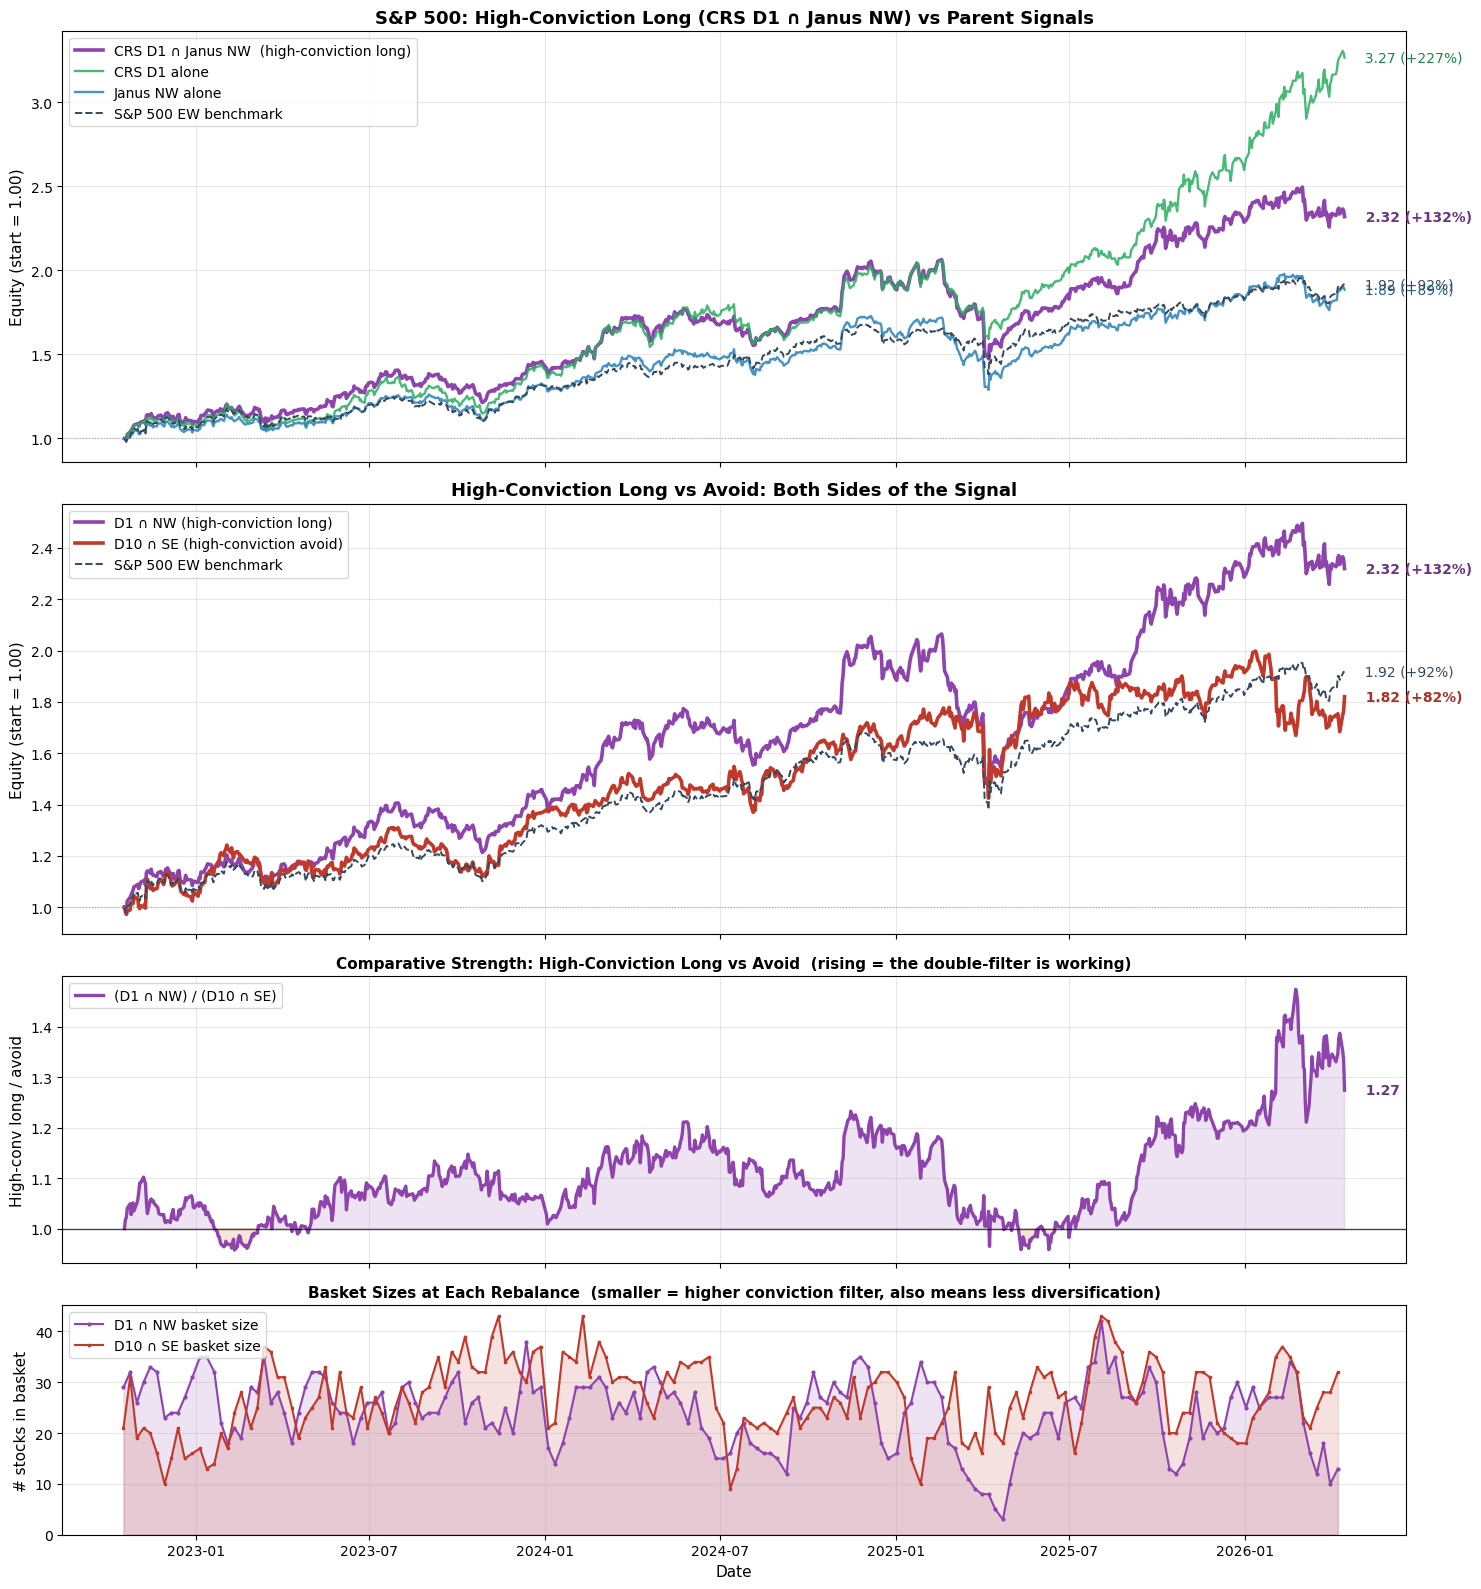

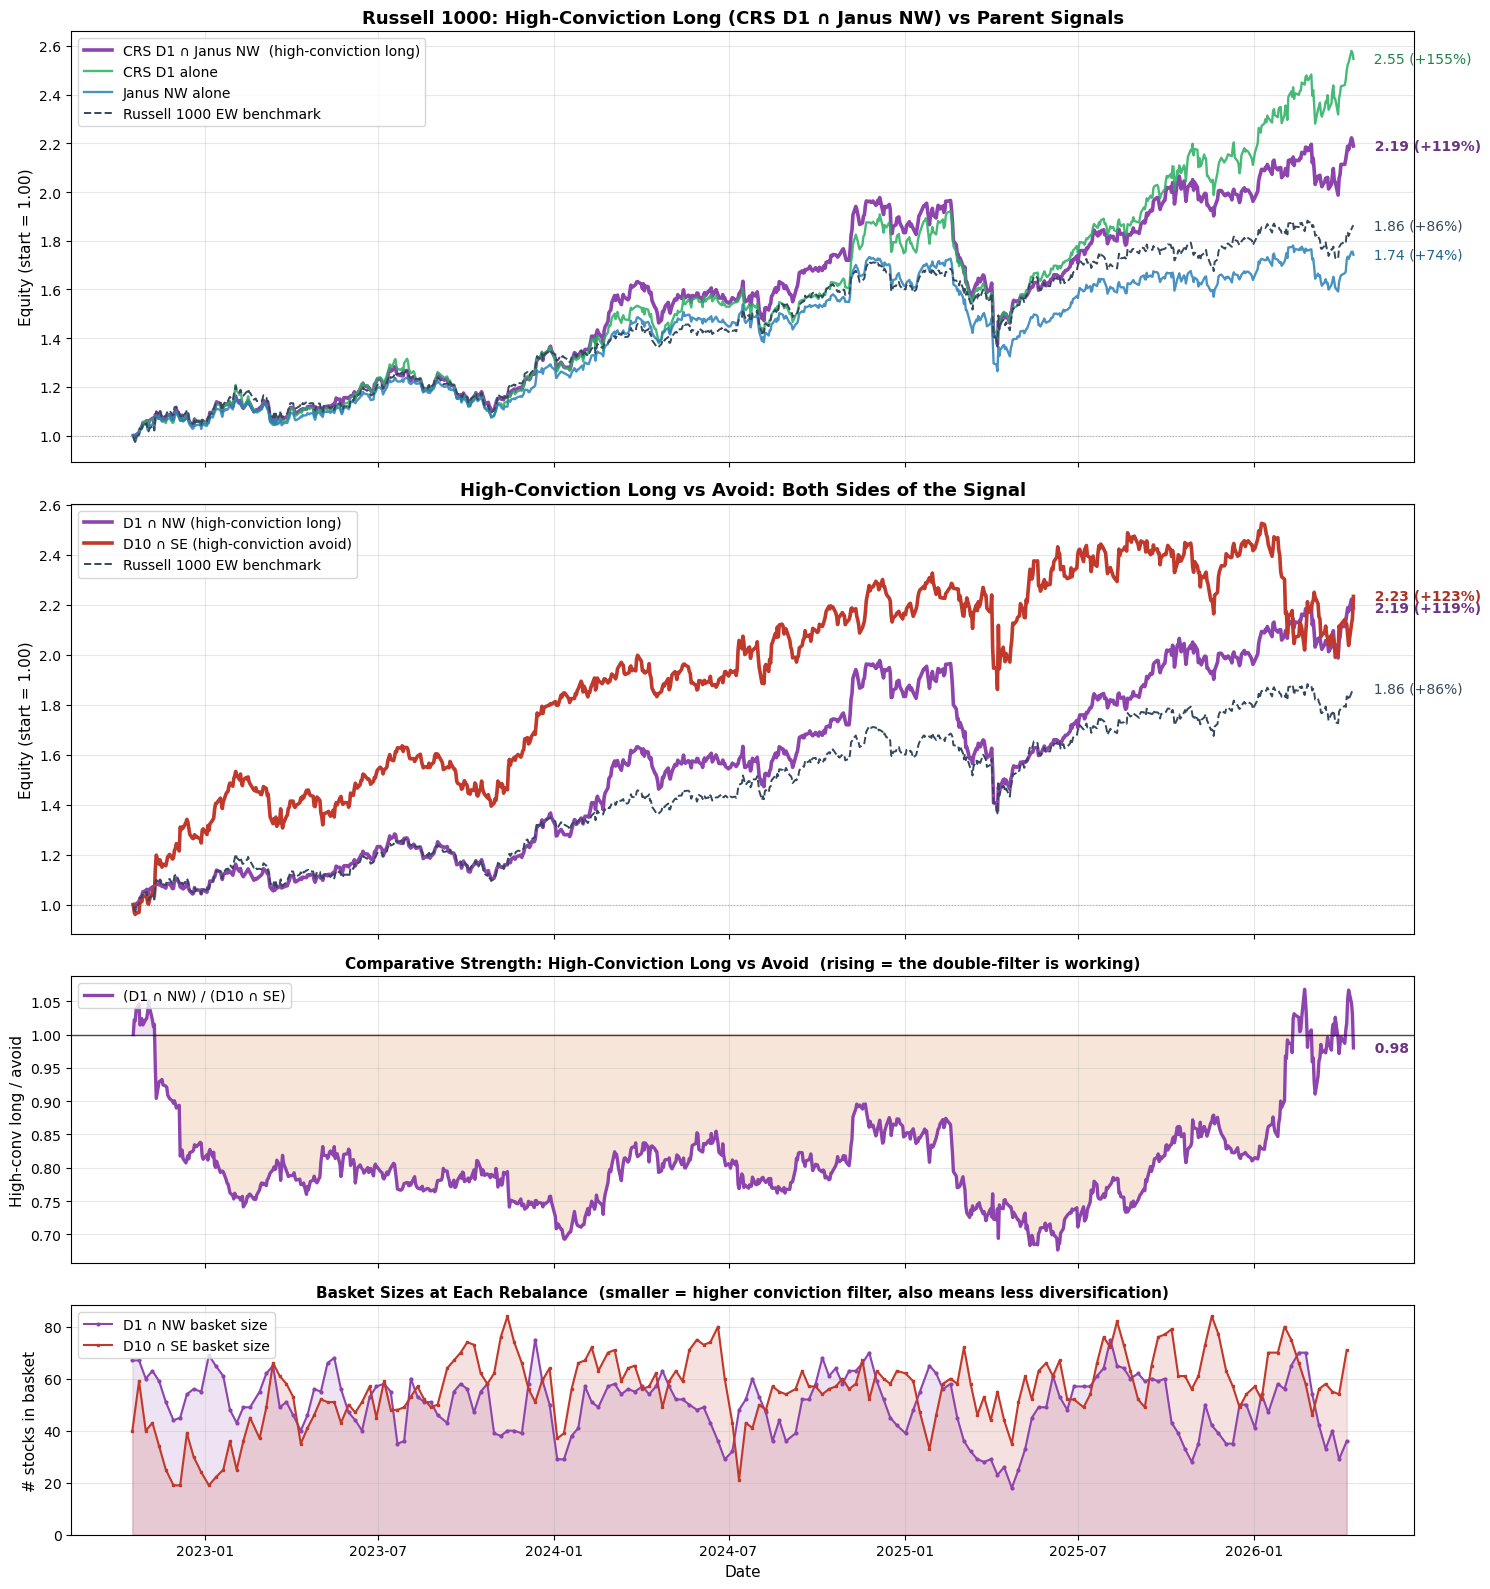



  S&P 500  —  Current High-Conviction Rosters (as of rebalance 2026-04-08)

--------------------------------------------------------------------------------------------------------------
  D1 ∩ NW — HIGH-CONVICTION LONGS  (13 names)
--------------------------------------------------------------------------------------------------------------
 Rank Ticker  Close   OFF  DEF    RS Ret_21d Ret_63d Ret_126d
    1   LITE 896.02 497.9 57.3 311.5  +39.9% +125.5%  +457.9%
    2   SNDK 780.90 519.8 90.7 303.5  +32.6% +123.4%  +544.5%
    3   DELL 185.47 217.5 34.0 129.8  +26.6%  +50.3%   +28.3%
    4   AKAM 116.00 129.5  0.3  91.4  +13.6%  +30.7%   +47.9%
    5   CASY 758.37 131.8 11.5  85.0  +14.1%  +34.6%   +36.0%
    6   SATS 122.82 202.9 99.4  73.2  +11.7%   +5.8%   +60.0%
    7    SLB  51.88 126.6 23.4  73.0   +9.9%  +19.6%   +52.1%
    8   ODFL 207.53 179.1 88.4  64.2   +5.2%  +23.1%   +45.8%
    9    ADI 346.21 172.9 83.8  63.0   +8.3%  +18.6%   +43.7%
   10    WAB 269.66 154.3 65.2  62

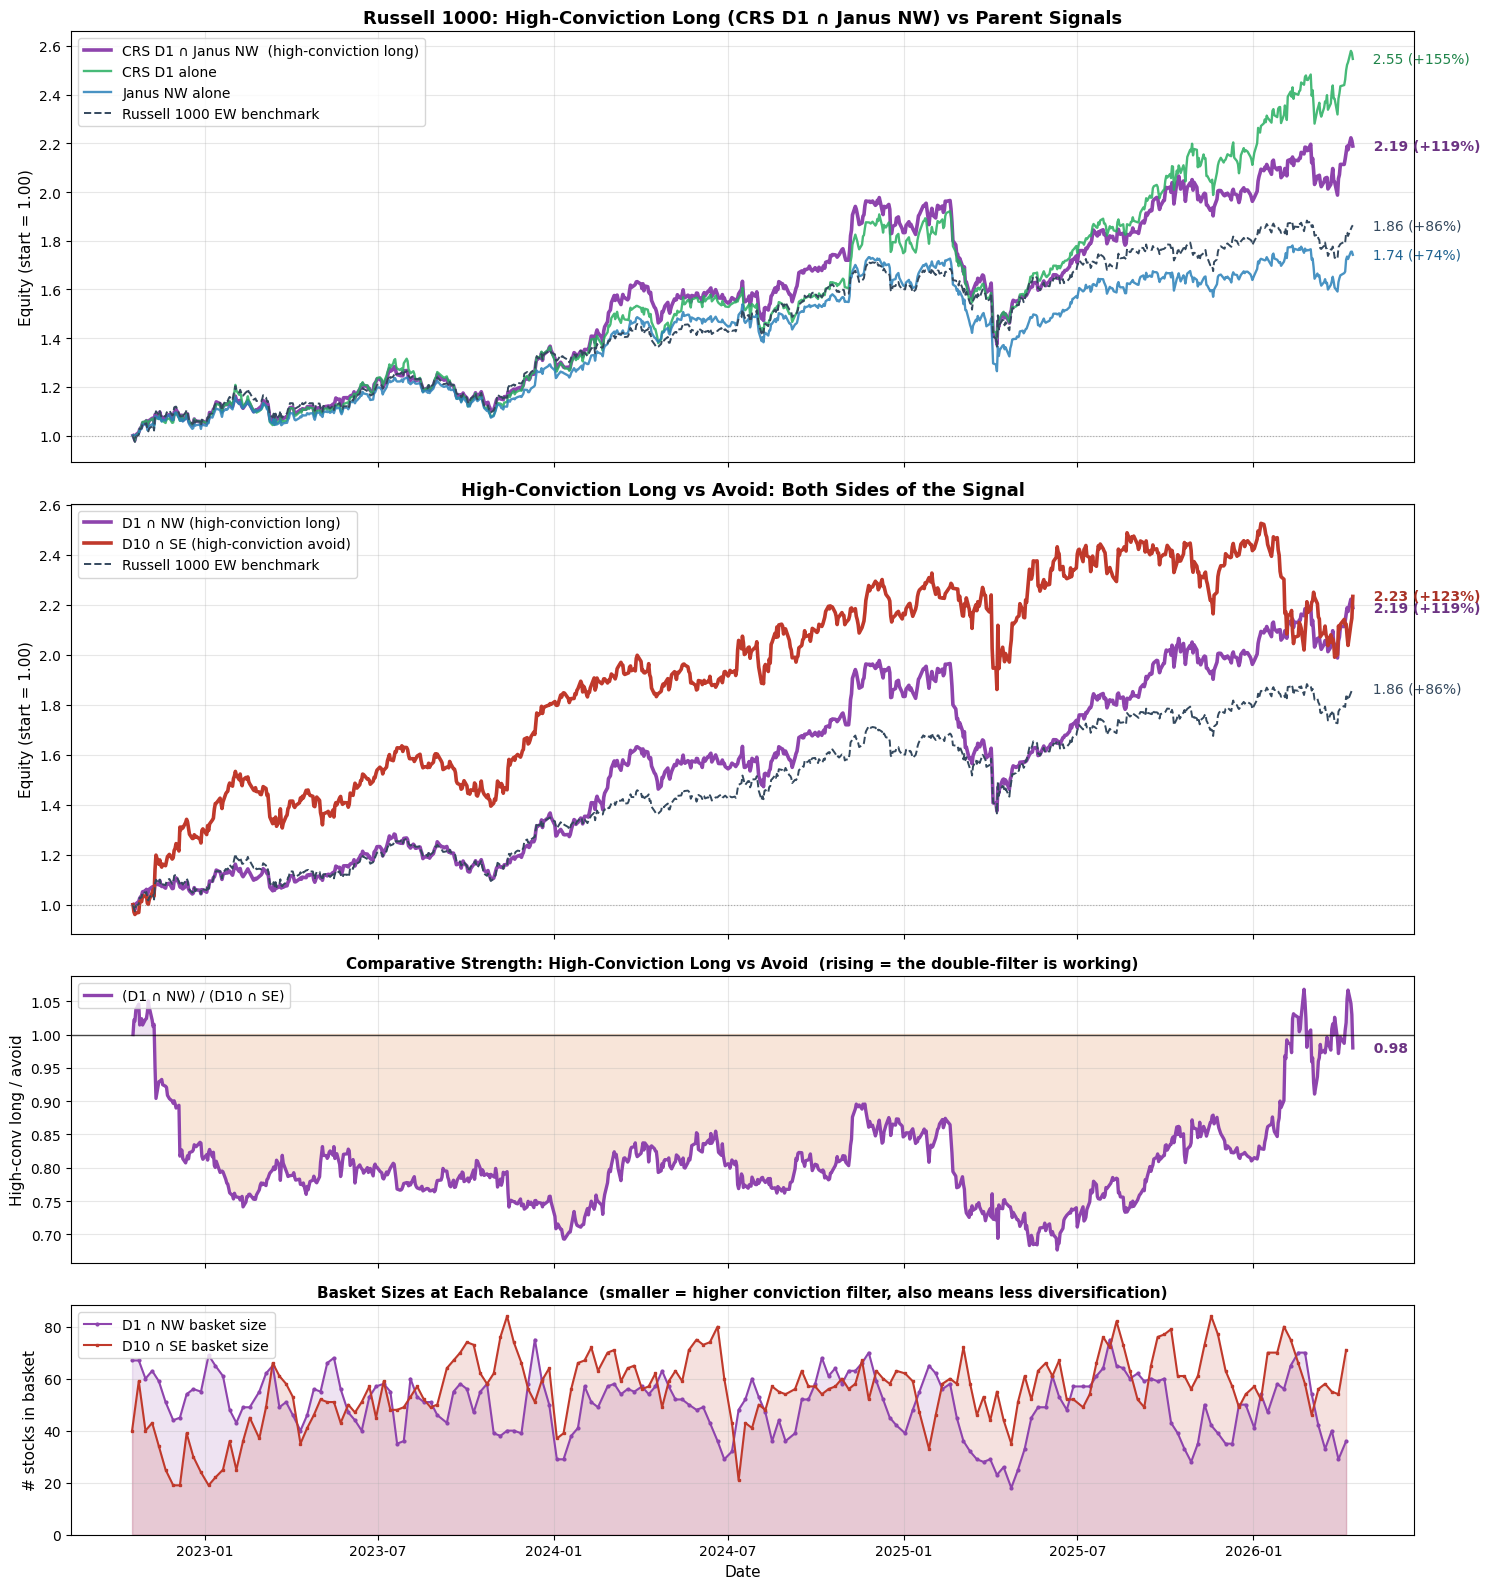



  S&P 500  —  Current High-Conviction Rosters (as of rebalance 2026-04-08)

--------------------------------------------------------------------------------------------------------------
  D1 ∩ NW — HIGH-CONVICTION LONGS  (13 names)
--------------------------------------------------------------------------------------------------------------
 Rank Ticker  Close   OFF  DEF    RS Ret_21d Ret_63d Ret_126d
    1   LITE 896.02 497.9 57.3 311.5  +39.9% +125.5%  +457.9%
    2   SNDK 780.90 519.8 90.7 303.5  +32.6% +123.4%  +544.5%
    3   DELL 185.47 217.5 34.0 129.8  +26.6%  +50.3%   +28.3%
    4   AKAM 116.00 129.5  0.3  91.4  +13.6%  +30.7%   +47.9%
    5   CASY 758.37 131.8 11.5  85.0  +14.1%  +34.6%   +36.0%
    6   SATS 122.82 202.9 99.4  73.2  +11.7%   +5.8%   +60.0%
    7    SLB  51.88 126.6 23.4  73.0   +9.9%  +19.6%   +52.1%
    8   ODFL 207.53 179.1 88.4  64.2   +5.2%  +23.1%   +45.8%
    9    ADI 346.21 172.9 83.8  63.0   +8.3%  +18.6%   +43.7%
   10    WAB 269.66 154.3 65.2  62

In [17]:
# =====================================================================
# 10.7  High-Conviction Basket: CRS × Janus Intersection Backtest
# ---------------------------------------------------------------------
# At each 5-day rebalance, we intersect the two signal systems:
#   - HIGH CONVICTION LONG  = CRS D1 ∩ Janus NW  (top decile AND strong off+def)
#   - HIGH CONVICTION AVOID = CRS D10 ∩ Janus SE (bottom decile AND weak off+def)
#
# This is point-in-time honest: at each historical rebalance, we only use
# data available at that date to form the basket, then hold it forward 5 days.
# No survivorship bias from using today's membership list backwards.
# =====================================================================


def run_high_conviction_backtest(close_prices, crs_bt, janus_bt,
                                  off_matrix, def_matrix, rebal_period=5):
    """
    Walk the CRS rebalance grid (master schedule). At each rebalance date, form:
      - D1_NW basket (intersection of CRS top decile & Janus NW)
      - D10_SE basket (intersection of CRS bottom decile & Janus SE)
    Hold equal-weight long until next rebalance.

    Janus quadrants are looked up directly from the OFF/DEF matrices at each
    CRS rebalance date (matrices are computed daily, so every CRS rebal date
    will have valid Janus scores once past the warmup period).
    """
    dates = close_prices.index
    daily_rets = close_prices.pct_change()

    # Use CRS rebal_dates as the master schedule
    rebal_dates = crs_bt['rebal_dates']

    # Janus warmup — skip any CRS rebal dates earlier than when Janus first had
    # valid scores (i.e., before both benchmark and stocks had 126 days of data).
    janus_first_valid = off_matrix.dropna(how='all').index[0]
    rebal_dates = [d for d in rebal_dates if d >= janus_first_valid]

    d1nw_rets, d10se_rets = {}, {}
    d1nw_members, d10se_members = {}, {}
    d1nw_sizes, d10se_sizes = {}, {}

    for i, reb in enumerate(rebal_dates):
        nxt = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else dates[-1]
        fwd_mask = (dates > reb) & (dates <= nxt)
        fwd_dates = dates[fwd_mask]
        if len(fwd_dates) == 0:
            continue

        # CRS membership comes directly from CRS backtest state
        crs_d1 = set(crs_bt['d1_members'].get(reb, []))
        crs_d10 = set(crs_bt['d10_members'].get(reb, []))

        # Janus quadrants computed on-the-fly from the OFF/DEF matrices at this date
        if reb not in off_matrix.index:
            continue
        off_row = off_matrix.loc[reb]
        def_row = def_matrix.loc[reb]
        quads = assign_quadrants(off_row, def_row)
        jan_nw = set(quads[quads == 'NW'].index)
        jan_se = set(quads[quads == 'SE'].index)

        # Intersections
        d1_nw_basket = sorted(crs_d1 & jan_nw)
        d10_se_basket = sorted(crs_d10 & jan_se)

        d1nw_members[reb] = d1_nw_basket
        d10se_members[reb] = d10_se_basket
        d1nw_sizes[reb] = len(d1_nw_basket)
        d10se_sizes[reb] = len(d10_se_basket)

        # Forward equal-weight returns
        d1nw_cols = [c for c in d1_nw_basket if c in daily_rets.columns]
        d10se_cols = [c for c in d10_se_basket if c in daily_rets.columns]

        d1nw_fwd = (daily_rets.loc[fwd_dates, d1nw_cols].mean(axis=1)
                    if d1nw_cols else pd.Series(0.0, index=fwd_dates))
        d10se_fwd = (daily_rets.loc[fwd_dates, d10se_cols].mean(axis=1)
                     if d10se_cols else pd.Series(0.0, index=fwd_dates))

        for dt in fwd_dates:
            d1nw_rets[dt] = d1nw_fwd.loc[dt]
            d10se_rets[dt] = d10se_fwd.loc[dt]

    return {
        'd1nw_returns':  pd.Series(d1nw_rets).sort_index(),
        'd10se_returns': pd.Series(d10se_rets).sort_index(),
        'd1nw_members':  d1nw_members,
        'd10se_members': d10se_members,
        'd1nw_sizes':    pd.Series(d1nw_sizes).sort_index(),
        'd10se_sizes':   pd.Series(d10se_sizes).sort_index(),
        'rebal_dates':   rebal_dates,
    }


def compute_performance_stats(returns, annual_factor=252):
    """Standard performance stats on a daily return series."""
    r = returns.dropna()
    if len(r) < 10:
        return {k: np.nan for k in ['cagr', 'sharpe', 'vol', 'max_dd', 'calmar',
                                     'total_return', 'n_days']}
    eq = (1 + r).cumprod()
    n_years = len(r) / annual_factor
    total_return = eq.iloc[-1] - 1
    cagr = eq.iloc[-1] ** (1 / n_years) - 1 if n_years > 0 else np.nan
    vol = r.std() * np.sqrt(annual_factor)
    sharpe = r.mean() / r.std() * np.sqrt(annual_factor) if r.std() > 0 else np.nan
    running_max = eq.expanding().max()
    dd = eq / running_max - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan
    return {
        'cagr':         cagr,
        'sharpe':       sharpe,
        'vol':          vol,
        'max_dd':       max_dd,
        'calmar':       calmar,
        'total_return': total_return,
        'n_days':       len(r),
    }


def plot_high_conviction(hc_bt, crs_bt, janus_bt, universe_label):
    """
    Four-panel plot showing the high-conviction basket vs its parent signals.

    Panel 1: Four equity curves — D1∩NW, CRS D1, Janus NW, EW benchmark
    Panel 2: D1∩NW vs D10∩SE absolute equity curves + EW benchmark
    Panel 3: D1∩NW divided by D10∩SE (comparative strength line)
    Panel 4: Basket sizes over time (stacked: D1∩NW and D10∩SE)
    """
    d1nw_eq  = (1 + hc_bt['d1nw_returns']).cumprod()
    d10se_eq = (1 + hc_bt['d10se_returns']).cumprod()
    crs_d1_eq  = (1 + crs_bt['d1_returns']).cumprod()
    jan_nw_eq  = (1 + janus_bt['nw_returns']).cumprod()
    ew_eq      = (1 + crs_bt['ew_returns']).cumprod()

    # Align all series to the high-conviction date range for fair comparison
    common_idx = d1nw_eq.index.intersection(crs_d1_eq.index).intersection(
                   jan_nw_eq.index).intersection(ew_eq.index)
    d1nw_eq_a = d1nw_eq.reindex(common_idx)
    crs_d1_eq_a = crs_d1_eq.reindex(common_idx)
    jan_nw_eq_a = jan_nw_eq.reindex(common_idx)
    ew_eq_a = ew_eq.reindex(common_idx)
    d10se_eq_a = d10se_eq.reindex(common_idx)

    # Re-base everything to start at 1.0 on the common start date
    for s in [d1nw_eq_a, crs_d1_eq_a, jan_nw_eq_a, ew_eq_a, d10se_eq_a]:
        s /= s.iloc[0]

    fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True,
                              gridspec_kw={'height_ratios': [1.5, 1.5, 1.0, 0.8]})

    # -------- Panel 1: High-conviction long vs parent signals --------
    ax = axes[0]
    ax.plot(d1nw_eq_a.index, d1nw_eq_a.values,
            label='CRS D1 ∩ Janus NW  (high-conviction long)',
            color='#8e44ad', linewidth=2.6)
    ax.plot(crs_d1_eq_a.index, crs_d1_eq_a.values,
            label='CRS D1 alone', color='#27ae60', linewidth=1.7, alpha=0.85)
    ax.plot(jan_nw_eq_a.index, jan_nw_eq_a.values,
            label='Janus NW alone', color='#2980b9', linewidth=1.7, alpha=0.85)
    ax.plot(ew_eq_a.index, ew_eq_a.values,
            label=f'{universe_label} EW benchmark',
            color='#34495e', linewidth=1.4, linestyle='--')
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

    # Annotate final values
    last_x = common_idx[-1]
    def _ann(ax, y, text, color, bold=False):
        ax.annotate(f"  {text}", xy=(last_x, y), xytext=(8, 0),
                    textcoords='offset points', color=color, fontsize=10,
                    fontweight=('bold' if bold else 'normal'), va='center')
    _ann(ax, d1nw_eq_a.iloc[-1],
          f"{d1nw_eq_a.iloc[-1]:.2f} ({(d1nw_eq_a.iloc[-1]-1)*100:+.0f}%)",
          '#6c3483', bold=True)
    _ann(ax, crs_d1_eq_a.iloc[-1],
          f"{crs_d1_eq_a.iloc[-1]:.2f} ({(crs_d1_eq_a.iloc[-1]-1)*100:+.0f}%)",
          '#1e8449')
    _ann(ax, jan_nw_eq_a.iloc[-1],
          f"{jan_nw_eq_a.iloc[-1]:.2f} ({(jan_nw_eq_a.iloc[-1]-1)*100:+.0f}%)",
          '#1f6391')
    _ann(ax, ew_eq_a.iloc[-1],
          f"{ew_eq_a.iloc[-1]:.2f} ({(ew_eq_a.iloc[-1]-1)*100:+.0f}%)",
          '#34495e')

    ax.set_ylabel('Equity (start = 1.00)', fontsize=11)
    ax.set_title(f'{universe_label}: High-Conviction Long (CRS D1 ∩ Janus NW) '
                  f'vs Parent Signals',
                  fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

    # -------- Panel 2: High-conviction long vs avoid --------
    ax = axes[1]
    ax.plot(d1nw_eq_a.index, d1nw_eq_a.values,
            label='D1 ∩ NW (high-conviction long)',
            color='#8e44ad', linewidth=2.6)
    ax.plot(d10se_eq_a.index, d10se_eq_a.values,
            label='D10 ∩ SE (high-conviction avoid)',
            color='#c0392b', linewidth=2.6)
    ax.plot(ew_eq_a.index, ew_eq_a.values,
            label=f'{universe_label} EW benchmark',
            color='#34495e', linewidth=1.4, linestyle='--')
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    _ann(ax, d1nw_eq_a.iloc[-1],
          f"{d1nw_eq_a.iloc[-1]:.2f} ({(d1nw_eq_a.iloc[-1]-1)*100:+.0f}%)",
          '#6c3483', bold=True)
    _ann(ax, d10se_eq_a.iloc[-1],
          f"{d10se_eq_a.iloc[-1]:.2f} ({(d10se_eq_a.iloc[-1]-1)*100:+.0f}%)",
          '#a93226', bold=True)
    _ann(ax, ew_eq_a.iloc[-1],
          f"{ew_eq_a.iloc[-1]:.2f} ({(ew_eq_a.iloc[-1]-1)*100:+.0f}%)",
          '#34495e')

    ax.set_ylabel('Equity (start = 1.00)', fontsize=11)
    ax.set_title('High-Conviction Long vs Avoid: Both Sides of the Signal',
                  fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

    # -------- Panel 3: D1∩NW divided by D10∩SE --------
    ax = axes[2]
    ratio = d1nw_eq_a / d10se_eq_a
    ax.plot(ratio.index, ratio.values, color='#8e44ad', linewidth=2.4,
             label='(D1 ∩ NW) / (D10 ∩ SE)')
    ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.7)
    ax.fill_between(ratio.index, 1.0, ratio.values,
                     where=(ratio.values >= 1.0),
                     alpha=0.15, color='#8e44ad', interpolate=True)
    ax.fill_between(ratio.index, 1.0, ratio.values,
                     where=(ratio.values < 1.0),
                     alpha=0.15, color='#d35400', interpolate=True)
    _ann(ax, ratio.iloc[-1], f"{ratio.iloc[-1]:.2f}", '#6c3483', bold=True)
    ax.set_ylabel('High-conv long / avoid', fontsize=11)
    ax.set_title('Comparative Strength: High-Conviction Long vs Avoid  '
                  '(rising = the double-filter is working)',
                  fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)

    # -------- Panel 4: Basket sizes over time --------
    ax = axes[3]
    ax.plot(hc_bt['d1nw_sizes'].index, hc_bt['d1nw_sizes'].values,
             color='#8e44ad', linewidth=1.5, marker='o', markersize=2,
             label='D1 ∩ NW basket size')
    ax.plot(hc_bt['d10se_sizes'].index, hc_bt['d10se_sizes'].values,
             color='#c0392b', linewidth=1.5, marker='s', markersize=2,
             label='D10 ∩ SE basket size')
    ax.fill_between(hc_bt['d1nw_sizes'].index, 0, hc_bt['d1nw_sizes'].values,
                     alpha=0.15, color='#8e44ad')
    ax.fill_between(hc_bt['d10se_sizes'].index, 0, hc_bt['d10se_sizes'].values,
                     alpha=0.15, color='#c0392b')
    ax.set_ylabel('# stocks in basket', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_title('Basket Sizes at Each Rebalance  '
                  '(smaller = higher conviction filter, also means less diversification)',
                  fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()


def display_performance_table(hc_bt, crs_bt, janus_bt, universe_label):
    """Side-by-side performance stats table for all six strategies."""
    strategies = {
        'D1 ∩ NW (high-conv long)':   hc_bt['d1nw_returns'],
        'D10 ∩ SE (high-conv avoid)': hc_bt['d10se_returns'],
        'CRS D1 alone':               crs_bt['d1_returns'],
        'CRS D10 alone':              crs_bt['d10_returns'],
        'Janus NW alone':             janus_bt['nw_returns'],
        'Janus SE alone':             janus_bt['se_returns'],
        'EW benchmark':               crs_bt['ew_returns'],
    }

    rows = []
    for name, rets in strategies.items():
        stats = compute_performance_stats(rets)
        rows.append({
            'Strategy': name,
            'CAGR':      f"{stats['cagr']*100:+.1f}%" if pd.notna(stats['cagr']) else '—',
            'Sharpe':    f"{stats['sharpe']:.2f}"    if pd.notna(stats['sharpe']) else '—',
            'Vol':       f"{stats['vol']*100:.1f}%"  if pd.notna(stats['vol']) else '—',
            'Max DD':    f"{stats['max_dd']*100:+.1f}%" if pd.notna(stats['max_dd']) else '—',
            'Calmar':    f"{stats['calmar']:.2f}"    if pd.notna(stats['calmar']) else '—',
            'Total Ret': f"{stats['total_return']*100:+.1f}%" if pd.notna(stats['total_return']) else '—',
        })

    df = pd.DataFrame(rows)
    print("=" * 110)
    print(f"  {universe_label}  —  Performance Comparison")
    print("=" * 110)
    print(df.to_string(index=False))


def display_current_high_conviction(hc_bt, spx_or_r1k_prices, off_matrix, def_matrix,
                                     rs_matrix, universe_label):
    """Print the current (most recent rebalance) high-conviction rosters."""
    last_reb = max(hc_bt['d1nw_members'].keys())
    live_date = spx_or_r1k_prices.index[-1]

    def detail(tickers, ref_date, prices):
        rows = []
        for t in tickers:
            if t not in prices.columns:
                continue
            p = prices[t]
            if ref_date not in p.index or pd.isna(p.loc[ref_date]):
                continue
            p_now = p.loc[ref_date]
            idx = p.index.get_loc(ref_date)
            def lb(n):
                i0 = idx - n
                if i0 < 0 or pd.isna(p.iloc[i0]):
                    return np.nan
                return (p_now / p.iloc[i0] - 1) * 100
            rows.append({
                'Ticker':  t,
                'Close':   p_now,
                'OFF': off_matrix.loc[ref_date, t] if t in off_matrix.columns else np.nan,
                'DEF': def_matrix.loc[ref_date, t] if t in def_matrix.columns else np.nan,
                'RS':  rs_matrix.loc[ref_date, t]  if t in rs_matrix.columns  else np.nan,
                'Ret_21d':  lb(21),
                'Ret_63d':  lb(63),
                'Ret_126d': lb(126),
            })
        df = pd.DataFrame(rows)
        if len(df):
            df = df.sort_values('RS', ascending=False).reset_index(drop=True)
            df.insert(0, 'Rank', range(1, len(df) + 1))
        return df

    d1nw_df = detail(hc_bt['d1nw_members'][last_reb], last_reb, spx_or_r1k_prices)
    d10se_df = detail(hc_bt['d10se_members'][last_reb], last_reb, spx_or_r1k_prices)

    print("=" * 110)
    print(f"  {universe_label}  —  Current High-Conviction Rosters (as of rebalance {last_reb.date()})")
    print("=" * 110)

    for title, df in [
        ("D1 ∩ NW — HIGH-CONVICTION LONGS", d1nw_df),
        ("D10 ∩ SE — HIGH-CONVICTION AVOIDS", d10se_df),
    ]:
        print("\n" + "-" * 110)
        print(f"  {title}  ({len(df)} names)")
        print("-" * 110)
        if len(df) == 0:
            print("  (empty — signals not agreeing at the extremes this rebalance)")
            continue
        disp = df.copy()
        for c in ['Close']:
            disp[c] = disp[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
        for c in ['OFF', 'DEF', 'RS']:
            disp[c] = disp[c].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
        for c in ['Ret_21d', 'Ret_63d', 'Ret_126d']:
            disp[c] = disp[c].map(lambda x: f"{x:+.1f}%" if pd.notna(x) else "—")
        print(disp.to_string(index=False))


# =====================================================================
# Run for both universes
# =====================================================================
print("=" * 70)
print("  HIGH-CONVICTION BACKTEST (CRS × Janus intersection)")
print("=" * 70)

print("\n[1/2] S&P 500…")
spx_hc_bt = run_high_conviction_backtest(spx_prices, spx_bt, spx_janus_bt,
                                          spx_off, spx_def, REBAL_PERIOD)
print(f"  D1 ∩ NW avg basket size:  {spx_hc_bt['d1nw_sizes'].mean():.1f}  "
      f"(min={spx_hc_bt['d1nw_sizes'].min()}, max={spx_hc_bt['d1nw_sizes'].max()})")
print(f"  D10 ∩ SE avg basket size: {spx_hc_bt['d10se_sizes'].mean():.1f}  "
      f"(min={spx_hc_bt['d10se_sizes'].min()}, max={spx_hc_bt['d10se_sizes'].max()})")

print("\n[2/2] Russell 1000…")
r1k_hc_bt = run_high_conviction_backtest(r1k_prices, r1k_bt, r1k_janus_bt,
                                          r1k_off, r1k_def, REBAL_PERIOD)
print(f"  D1 ∩ NW avg basket size:  {r1k_hc_bt['d1nw_sizes'].mean():.1f}  "
      f"(min={r1k_hc_bt['d1nw_sizes'].min()}, max={r1k_hc_bt['d1nw_sizes'].max()})")
print(f"  D10 ∩ SE avg basket size: {r1k_hc_bt['d10se_sizes'].mean():.1f}  "
      f"(min={r1k_hc_bt['d10se_sizes'].min()}, max={r1k_hc_bt['d10se_sizes'].max()})")

# Performance tables
print()
display_performance_table(spx_hc_bt, spx_bt, spx_janus_bt, 'S&P 500')
print()
display_performance_table(r1k_hc_bt, r1k_bt, r1k_janus_bt, 'Russell 1000')

# Equity curve plots
print("\n")
plot_high_conviction(spx_hc_bt, spx_bt, spx_janus_bt, 'S&P 500')
plot_high_conviction(r1k_hc_bt, r1k_bt, r1k_janus_bt, 'Russell 1000')

# Current high-conviction rosters
print("\n")
display_current_high_conviction(spx_hc_bt, spx_prices, spx_off, spx_def, spx_rs, 'S&P 500')
print("\n\n")
display_current_high_conviction(r1k_hc_bt, r1k_prices, r1k_off, r1k_def, r1k_rs, 'Russell 1000')

---
## 7. Quantum Machine Learning Filter (VQNet)

This section implements a Hybrid Quantum-Classical Neural Network (HQCNN) using Origin Quantum's `pyvqnet` framework.
The model is trained to classify the D1 (top decile) watchlist candidates into "High Conviction" (predicted to outperform the EW benchmark over the next 5 days) and "Low Conviction" based on 4 momentum features.

**Features (4 Qubits):**
- 21-day momentum
- 63-day momentum
- 126-day momentum
- 5-day short-term momentum

**Label:** 
- 1 if 5-day forward return > EW Benchmark return, else 0.


In [ ]:
# Feature & Label Engineering
import numpy as np
import pandas as pd

# We use the S&P 500 universe for training the QML model
prices = spx_prices
daily_rets = prices.pct_change()
rebal_dates = spx_bt['rebal_dates']
ew_returns = spx_bt['ew_returns']
d1_members = spx_bt['d1_members']

# 1. Feature Extraction (21, 63, 126, 5 day momentum)
lookbacks_qml = [21, 63, 126, 5]

print("Extracting features for VQNet...")
X_list = []
y_list = []
dates_list = []
tickers_list = []

for i in range(len(rebal_dates) - 1):
    reb = rebal_dates[i]
    nxt = rebal_dates[i+1]
    
    # Target label: outperformance vs EW benchmark over the forward period
    fwd_mask = (prices.index > reb) & (prices.index <= nxt)
    fwd_dates = prices.index[fwd_mask]
    if len(fwd_dates) == 0:
        continue
    
    ew_fwd_ret = (1 + ew_returns.loc[fwd_dates]).prod() - 1
    
    # We only care about D1 members to filter them
    d1_stocks = d1_members[reb]
    
    for ticker in d1_stocks:
        if ticker not in prices.columns:
            continue
            
        # Get features
        features = []
        valid = True
        for lb in lookbacks_qml:
            idx = prices.index.get_loc(reb)
            if idx - lb < 0:
                valid = False
                break
            past_price = prices[ticker].iloc[idx - lb]
            if pd.isna(past_price) or past_price == 0:
                valid = False
                break
            # Momentum
            mom = prices[ticker].loc[reb] / past_price
            features.append(mom)
            
        if not valid:
            continue
            
        # Get label
        ticker_fwd_ret = (1 + daily_rets[ticker].loc[fwd_dates]).prod() - 1
        label = 1 if ticker_fwd_ret > ew_fwd_ret else 0
        
        X_list.append(features)
        y_list.append([label, 1 - label]) # Categorical format: [Outperform, Underperform]
        dates_list.append(reb)
        tickers_list.append(ticker)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

# Normalize features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / (X_std + 1e-8)

print(f"Dataset extracted: {X_norm.shape[0]} samples with {X_norm.shape[1]} features.")


In [ ]:
# VQNet Model Architecture & Training
import pyvqnet
from pyvqnet.nn.module import Module
from pyvqnet.nn.linear import Linear
from pyvqnet.nn.loss import CategoricalCrossEntropy
from pyvqnet.optim.adam import Adam
from pyvqnet.data.data import data_generator
from pyvqnet.tensor import tensor
from pyvqnet.tensor.tensor import QTensor
from pyvqnet.qnn.vqc import QMachine, QModule, ry, rz, cnot, MeasureAll
from pyvqnet.nn import Parameter

num_qubits = 4
depth = 2

def q_encode(qm, features, qubits):
    for i in range(len(qubits)):
        ry(qm, i, features[:, [i]])

def q_variational(qm, weights, qubits):
    for k in range(depth):
        # Entanglement
        for i in range(len(qubits) - 1):
            cnot(qm, [qubits[i], qubits[i+1]])
        cnot(qm, [qubits[-1], qubits[0]])
        # Rotations
        for i in range(len(qubits)):
            ry(qm, i, weights[k, 0, i])
            rz(qm, i, weights[k, 1, i])

class QFilterCircuit(QModule):
    def __init__(self, nq):
        super(QFilterCircuit, self).__init__()
        self.qm = QMachine(nq)
        self.nq = nq
        self.w = Parameter((depth, 2, nq))
        
        obs_list = [{"Z" + str(i): 1.0} for i in range(nq)]
        self.ma = MeasureAll(obs=obs_list)

    def forward(self, x):
        self.qm.reset_states(x.shape[0])
        qubits = range(self.nq)
        q_encode(self.qm, x, qubits)
        q_variational(self.qm, self.w, qubits)
        return self.ma(self.qm)

class HQCNN_Filter(Module):
    def __init__(self):
        super(HQCNN_Filter, self).__init__()
        self.q_layer = QFilterCircuit(num_qubits)
        self.fc = Linear(num_qubits, 2)

    def forward(self, x):
        x = self.q_layer(x)
        x = self.fc(x)
        return x

# Train-Test Split (Chronological: 75% train, 25% test)
split_idx = int(len(X_norm) * 0.75)
X_train, y_train = X_norm[:split_idx], y[:split_idx]
X_test, y_test = X_norm[split_idx:], y[split_idx:]

print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples.")

model = HQCNN_Filter()
optimizer = Adam(model.parameters(), lr=0.01)
loss_func = CategoricalCrossEntropy()

epochs = 10
batch_size = 32

print("Training HQCNN...")
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0
    correct = 0
    n_train = 0
    for batch_x, batch_y in data_generator(X_train, y_train, batch_size=batch_size, shuffle=True):
        optimizer.zero_grad()
        batch_x_q = QTensor(batch_x)
        batch_y_q = QTensor(batch_y)
        output = model(batch_x_q)
        loss = loss_func(batch_y_q, output)
        loss.backward()
        optimizer._step()
        
        total_loss += loss.item()
        
        np_output = np.array(output.data, copy=False)
        mask = (np_output.argmax(1) == batch_y.argmax(1))
        correct += np.sum(np.array(mask))
        n_train += len(batch_x)
        
    train_acc = correct / n_train
    
    # Evaluate
    model.eval()
    test_correct = 0
    for batch_x, batch_y in data_generator(X_test, y_test, batch_size=batch_size, shuffle=False):
        batch_x_q = QTensor(batch_x)
        output = model(batch_x_q)
        np_output = np.array(output.data, copy=False)
        mask = (np_output.argmax(1) == batch_y.argmax(1))
        test_correct += np.sum(np.array(mask))
        
    test_acc = test_correct / len(X_test)
    
    print(f"Epoch {epoch}/{epochs} - Loss: {total_loss/n_train:.4f} - Train Acc: {train_acc:.4f} - Test Acc: {test_acc:.4f}")
print("Training completed.")


In [ ]:
# Watchlist Inference
# Get the D1 watchlist for the most recent rebalance
last_reb = rebal_dates[-1]
current_d1 = d1_members[last_reb]

qml_predictions = {}
print(f"Running Quantum Inference on current D1 candidates ({len(current_d1)} stocks)...")

model.eval()
for ticker in current_d1:
    if ticker not in prices.columns:
        continue
    
    features = []
    valid = True
    for lb in lookbacks_qml:
        idx = prices.index.get_loc(last_reb)
        if idx - lb < 0:
            valid = False
            break
        past_price = prices[ticker].iloc[idx - lb]
        if pd.isna(past_price) or past_price == 0:
            valid = False
            break
        features.append(prices[ticker].loc[last_reb] / past_price)
        
    if not valid:
        qml_predictions[ticker] = "Unknown"
        continue
        
    feature_arr = np.array([features], dtype=np.float32)
    feature_norm = (feature_arr - X_mean) / (X_std + 1e-8)
    
    q_input = QTensor(feature_norm)
    output = model(q_input)
    np_output = np.array(output.data, copy=False)
    pred_idx = np_output.argmax(1)[0]
    
    # Our mapping: index 0 is Outperform, index 1 is Underperform.
    if pred_idx == 0:
        qml_predictions[ticker] = "High Conviction"
    else:
        qml_predictions[ticker] = "Low Conviction"

# Display updated High Conviction D1
current_d1_df = pd.DataFrame({
    'Ticker': list(qml_predictions.keys()),
    'QML_Prediction': list(qml_predictions.values())
})

print("="*60)
print(f"  S&P 500 D1 Watchlist with Quantum Filter (as of {last_reb.date()})")
print("="*60)
high_conviction = current_d1_df[current_d1_df['QML_Prediction'] == 'High Conviction']
print(f"\n--- High Conviction QML Longs ({len(high_conviction)} names) ---")
print(high_conviction.to_string(index=False))

low_conviction = current_d1_df[current_d1_df['QML_Prediction'] == 'Low Conviction']
print(f"\n--- Low Conviction QML Longs ({len(low_conviction)} names) ---")
print(low_conviction.to_string(index=False))
